# 時間序列資料處理

### 以海洋熱浪與氣象浮標資料為例 

    海洋學門資料庫 翁其羽

## 投影片 2 — ODB Open API

網址：<https://api.odb.ntu.edu.tw/hub>

- **海洋研究船長期蒐集台灣周遭海域之船測資料**
  - **ODB CTD API**：溫鹽深儀（CTD）暨附屬探針資料：溫度、鹽度、溶氧、透光度、螢光度（39 yrs, 18 million records）
  - **ODB SADCP API**：船載都卜勒流剖儀（SADCP）海流 u、v 流速、流向資料（185 million records）
- **海洋科學家貢獻之資料集，或整理自其他公開文獻、合作計畫等**
  - **ODB ECO API**：海洋生物出現記錄（主要為浮游動物、仔稚魚等，172,691 records）與微塑膠資料集（23,189 records）
- **轉製海洋科學文獻方法、或由其他全球公開資料庫編譯**
  - **Marine Heatwaves (MHW) API**：全球海洋熱浪：1982- 迄今月均海表溫及距平值、熱浪級數等（533.95 million records）
  - **GEBCO (2026 Grid) Bathymetry API**：全球地形高程資料，15 弧秒（約 400 m）解析（3.732 billion records）
  - **Tide API**：TPXO10-atlas-v2 全球潮汐模型（874.96 million records）
  - **WOA23 API**：World Ocean Atlas 2023：溫度、鹽度、營養鹽、溶氧相關等長期平均資料（324.26 million records）
  - **GLODAP API**：GLODAP v2.2023（近 20 種水文化學參數）（1.49M global bottle data from 1,116 cruises, 1972–2021）
- **工具型 API**
  - **OGC WMS/WMTS Capabilities API**：查詢支援開放地理空間協會（OGC）WMS/WMTS 標準之地理圖層資訊

## 投影片 3 — Time-series Lecture Targets

- 找到適當的資料來源：**Open API**、網頁、文獻，並檢視其時空模式（**patterns**）
- 處理時間尺度或精細度不同的時間序列關係
- 初探時間序列分解（**decomposition**）

**資料來源：**
- 中央氣象署氣象浮標資料（**NODASS** 提供）、**ODB** 海洋熱浪 **MHW API**

**附註：**
- 時間有限，科普（如聖嬰、**Ekman transport**）、程式指令細節、套件安裝，請自行 **ask google or AI**

#### (投影片 4)
![投影片 4: ENSO 科普](./lectures/ENSO_popsci01.png)

## 投影片 5 — The Oceanic Niño Index (ONI)

<video width="960" autoplay loop muted playsinline>
  <source src="lectures/ENSO_vs_disease1.mp4" type="video/mp4">
您的瀏覽器不支援影片播放。
</video>

- **Niño 3.4 region: 5°N–5°S, 120°–170°W

###### 動畫：NIÑO 3.4 SST Anomaly Timeline & Disease Outbreaks by Helen-Nicole Kostis，from <https://svs.gsfc.nasa.gov/4765>


#### Code-1. 練習使用 Requests 發送網路 API 請求獲得 ODB 海洋熱浪資料

目標 

- 用 cartopy 畫一張跨換日線的赤道太平洋 SST 距平 (anomalies) 圖 - 2007-12，反聖嬰現象
- 資料：使用 ODB MHW API
- 技巧：由於會跨經度180°，API 參數的經緯度範圍是 -180 ~ 180, 因此在 180° 附近會產生邊界問題，需要分段處理。畫地圖則可將經度轉 0–360 後資料是連續的（不會在 180° 斷開），投影用 `PlateCarree(central_longitude=180)` 把太平洋擺中間，資料用 `transform=PlateCarree()`。

- 自我練習：改畫 2015-12，超強聖嬰

In [ ]:
!git clone https://github.com/ODBapp/2026_NODASS_workshop.git

In [ ]:
%cd 2026_NODASS_workshop/src/timeseries

In [60]:
import os
from pathlib import Path
os.chdir(Path().resolve()) 
print(os.getcwd())

'''
in Google Colab, the current path should be
/content/2026_NODASS_workshop/src/timeseries
'''

# Global settings for data
DATA_DIR = Path().resolve().parent / "data"
print(DATA_DIR)

NOAA_NINO34_URL = "https://psl.noaa.gov/data/timeseries/month/data/nino34.long.anom.data"
ODB_MHW_API = "https://eco.odb.ntu.edu.tw/api/mhw"


D:\proj\2025_NODASS_workshop\src\timeseries\2026
D:\proj\2025_NODASS_workshop\src\timeseries\data


In [61]:
'''
# --- in Google Colab to get correct data and enviroments ---
# !pip install Desired_Packages or after git clone, install by using requirements.txt
!git clone https://github.com/ODBapp/2026_NODASS_workshop.git
!pip install -r 2026_NODASS_workshop/requirements.txt
%cd 2026_NODASS_workshop/src/timeseries

# Note in Google Colab, if you install package by !pip, and need restart session, then you also need redo:
%cd 2026_NODASS_workshop/src/timeseries
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests, warnings

In [62]:
# Step 1: ODB Open API Fetch
def fetch_mhw_data(lon0, lat0, lon1=None, lat1=None, start=None, end=None,
                   timeout=40) -> pd.DataFrame:
    """
    直接打 ODB MHW API，回傳逐格點 DataFrame。API 手冊見 https://api.odb.ntu.edu.tw/hub/swagger?node=odb_mhw_v1
    給定 API 參數
    params = {
        "lon0": lon0,
        "lat0": lat0,
        "lon1": lon1,
        "lat1": lat1,
        "start": start,
        "end": end,
        "append": "sst,sst_anomaly,level",
    }

    - 給 lon1/lat1 → 範圍 (bbox) 查詢，但有時間長度上限。
    - 不給 lon1/lat1 → 「單點」查詢，只回傳該座標所落入的那一個 0.25° 格點，
      且無時間長度限制（可一次抓完 1982 至今）。    
    """

    params = dict(lon0=lon0, lat0=lat0, start=start, end=end,
                  append="sst,sst_anomaly,level")
    if lon1 is not None:
        params["lon1"] = lon1
    if lat1 is not None:
        params["lat1"] = lat1
    resp = requests.get(ODB_MHW_API, params=params, timeout=timeout)
    resp.raise_for_status()
    return pd.DataFrame(resp.json())

In [63]:
# 如何快速試驗function：切一小段 code，實際 呼叫 API，看看回傳的 DataFrame 長什麼樣子
# region for Niño 3.4 (5°N–5°S, 170°W–120°W)
lon0, lon1 = -170, -120  
lat0, lat1 = -5, 5
start, end = "2025-05-01", "2025-05-30"
data = fetch_mhw_data(lon0, lat0, lon1, lat1, start, end)
print(data.head())

       lon    lat        date  level        sst  sst_anomaly
0 -169.875 -4.875  2025-05-01      1  29.800001       0.6174
1 -169.625 -4.875  2025-05-01      1  29.786451       0.6125
2 -169.375 -4.875  2025-05-01      1  29.752903       0.5893
3 -169.125 -4.875  2025-05-01      1  29.705482       0.5486
4 -168.875 -4.875  2025-05-01      0  29.651613       0.4963


In [64]:
# Test a stronger La Niña event
# Plot a wider region, but it across 180°E antimeridian, so we need to split the data fetching 
start, end = "2007-12-01", "2007-12-30"
lat0, lat1 = -25, 25
lon0, lon1 = 135, -60  # 若用 0 - 360° 來表示經度則為 135° to 300°

In [65]:
# def get_combined_ssta_data():
east = fetch_mhw_data(-179.999, lat0, lon1, lat1, start, end)
west = fetch_mhw_data(lon0, lat0, 179.999, lat1, start, end)
# return 
data = pd.concat([west, east], ignore_index=True)
print(data.tail())

           lon     lat        date  level        sst  sst_anomaly
131795 -61.125  24.875  2007-12-01      0  25.037739      -0.2259
131796 -60.875  24.875  2007-12-01      0  25.023226      -0.2668
131797 -60.625  24.875  2007-12-01      0  25.008711      -0.3061
131798 -60.375  24.875  2007-12-01      0  25.026773      -0.3041
131799 -60.125  24.875  2007-12-01      0  25.059032      -0.2803


In [66]:
def load_enso_map(date="2007-12") -> pd.DataFrame:
    """
    太平洋 SST 距平格點 (跨換日線)。線上優先 (分兩段抓避開 API bbox 限制)，
    失敗則讀 data/enso_map_{date}.csv。回傳含 lon/lat/sst_anomaly 的 DataFrame。
    """
    cache = DATA_DIR / f"enso_map_{date}.csv"
    start = f"{date}-01"
    end = (pd.Timestamp(start) + pd.offsets.MonthEnd(1)).strftime("%Y-%m-%d")
    lon0, lon1 = 135, -60  # 180°E to 300°E
    lat0, lat1 = -25, 25
    try:
        # API 的 lon0..lon1 無法直接跨換日線，所以分東、西兩段抓再接起來
        west = fetch_mhw_data(lon0, lat0, 179.999, lat1, start, end)
        east = fetch_mhw_data(-179.999, lat0, lon1, lat1, start, end)
        df = pd.concat([west, east], ignore_index=True)
        df = df[["lon", "lat", "sst_anomaly"]]   # 只留繪圖需要的欄位，快取較小
        df.to_csv(cache, index=False)
    except Exception as exc:  # noqa: BLE001
        warnings.warn(f"ODB API 抓取失敗 ({exc})，改用本機快取 {cache.name}")
        df = pd.read_csv(cache)
    return df


In [67]:
# 重複這個試驗：切一小段 function code，實際看看產生的 DataFrame 長什麼樣子
df = load_enso_map('2007-12')       # 線上優先、失敗用快取
df["lon360"] = df["lon"] % 360      # 轉 0–360：跨太平洋變連續，注意python 的模數運算子(不是取餘數)，-120 % 360 答案是 240（即 360 - 120）
grid = df.pivot_table(index="lat", columns="lon360", values="sst_anomaly")
LON, LAT = np.meshgrid(grid.columns.values, grid.index.values) # 將這些經緯度資料點建立成二維網格
print(grid.tail())

lon360  135.125  135.375  135.625  135.875  136.125  136.375  136.625  \
lat                                                                     
23.875   1.7531   1.8582   1.9113   1.9267   1.8997   1.8697   1.8019   
24.125   1.6862   1.7756   1.8356   1.8694   1.8616   1.8102   1.7369   
24.375   1.3525   1.4342   1.5002   1.5590   1.5953   1.5676   1.5185   
24.625   0.7915   0.8438   0.9014   0.9674   1.0329   1.0542   1.0795   
24.875   0.2681   0.2775   0.2988   0.3461   0.4039   0.4687   0.5660   

lon360  136.875  137.125  137.375  ...  297.625  297.875  298.125  298.375  \
lat                                ...                                       
23.875   1.7190   1.6288   1.5484  ...   0.1542   0.2673   0.3876   0.4868   
24.125   1.6756   1.6214   1.5326  ...   0.1657   0.2401   0.3222   0.3720   
24.375   1.5091   1.5082   1.4260  ...   0.1347   0.1525   0.1547   0.1307   
24.625   1.1420   1.2073   1.1540  ...   0.1096   0.0591  -0.0118  -0.0864   
24.875   0.6614   0.

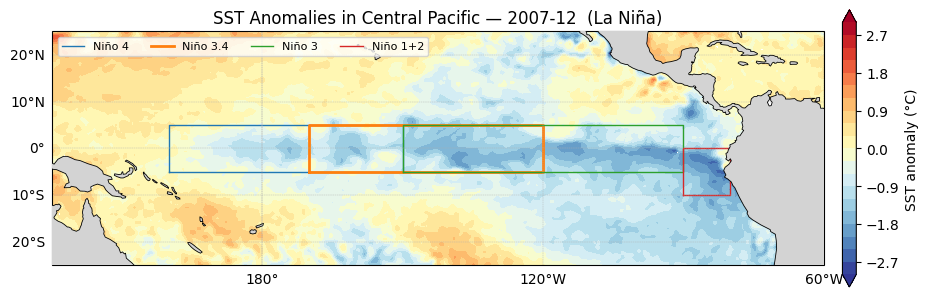

In [68]:
def plot_enso_map(date="2007-12", note="strong El Niño"):
    lon0, lon1 = 135, -60  # 180°E to 300°E
    lat0, lat1 = -25, 25
    df = load_enso_map(date)            # 線上優先、失敗用快取
    df["lon360"] = df["lon"] % 360      # 轉 0–360：跨太平洋變連續，注意python 的模數運算子(不是取餘數)，-120 % 360 答案是 240（即 360 - 120）
    grid = df.pivot_table(index="lat", columns="lon360", values="sst_anomaly")
    LON, LAT = np.meshgrid(grid.columns.values, grid.index.values) # 將這些經緯度資料點建立成二維網格

    proj = ccrs.PlateCarree(central_longitude=180) # Cartopy的等距圓柱投影
    data_crs = ccrs.PlateCarree()
    fig = plt.figure(figsize=(12, 4.5))
    ax = plt.axes(projection=proj)
    ax.set_extent([lon0 % 360, lon1 % 360, lat0, lat1], crs=data_crs)

    # 繪製填色等高線圖。transform=data_crs 告訴系統：LON 和 LAT 矩陣是原始經緯度。Cartopy 會自動計算這組經緯度在「以 180 度為中心的地圖 (proj)」上應該畫在什麼位置
    im = ax.contourf(LON, LAT, grid.values, levels=np.linspace(-3, 3, 21),
                     cmap="RdYlBu_r", extend="both", transform=data_crs)
    ax.add_feature(cfeature.LAND.with_scale("110m"), facecolor="lightgray", zorder=3)
    ax.coastlines("110m", lw=0.6, zorder=4)

     
    # Niño 區域框 (經度用 0–360)
    boxes = {
        'Niño 4':   (160, 210, -5, 5),     # 160E~150W
        'Niño 3.4': (190, 240, -5, 5),     # 170W~120W
        'Niño 3':   (210, 270, -5, 5),     # 150W~90W
        'Niño 1+2': (270, 280, -10, 0),    # 90W~80W
    }
    
    for name, (a, b, c, d) in boxes.items():
        lw = 2.0 if name == "Niño 3.4" else 1.0
        ax.plot([a, b, b, a, a], [c, c, d, d, c], transform=data_crs, lw=lw, label=name)

    gl = ax.gridlines(draw_labels=True, lw=0.3, ls="--")
    gl.top_labels = gl.right_labels = False
    plt.colorbar(im, ax=ax, orientation="vertical", shrink=0.8, pad=0.02,
                 label="SST anomaly (°C)")
    ax.legend(loc="upper left", fontsize=8, ncol=4)
    ax.set_title(f"SST Anomalies in Central Pacific — {date}  ({note})")
    # 注意：cartopy 的 gridline labels 與 plt.tight_layout() 會衝突，這裡不要用 tight_layout
    plt.show()



plot_enso_map("2007-12", note="La Niña")

#### Code-1. EX: 改畫 2015-12，超強聖嬰

```
# 想換成強聖嬰範例可改成: 
plot_enso_map("2015-12", note="strong El Niño")
```

- 你會看到赤道中東太平洋一條明顯的「暖舌」——這就是聖嬰現象最常被觀測的 pattern

- 也同時是投影片 7 上半部結果。附帶一提，ODB MHW API 也可透過線上 Swagger 介面很方便地試用：https://api.odb.ntu.edu.tw/hub/swagger?node=odb_mhw_v1
（但請勿輸入過大的時空範圍參數，避免太多資料灌入這個介面當掉）


#### Code-1 結論
為何要畫這張圖？我們確認在 Niño 3.4 這個區域的確最容易觀察到聖嬰或反聖嬰（以下簡稱為 **ENSO**: 聖嬰-南方震盪現象）的 pattern；也就是用這個區域的 anomalies 可以拿來做為聖嬰或反聖嬰發生的依據。
因此我們可以進一步根據這些事件去做統計，這是最先決的條件。如果這個區域不足以識別 ENSO，有時靈，有時不靈，那根據它做的統計分析根本就沒有意義。
另外也可以看到，在冬季很容易識別 ENSO patterns。接下來我們也會在時間序列上確認。

## 投影片 6 — ONI, El Niño and La Niña

然而，你看到的是用海表溫距平值(SST anomaly)畫出來的圖像 pattern, 我們如何 **定義/量化** ENSO 與它的強弱？

下述方式把「距平值」轉換成大家口中慣稱的「聖嬰年/反聖嬰年」：

1. **ONI (Oceanic Niño Index)** = Niño 3.4 區域海表溫距平值的 **3 個月移動平均**（平滑掉短期雜訊）。
2. **門檻**：ONI ≥ +0.5°C 偏暖、≤ −0.5°C 偏冷。
3. **事件**：必須**連續 ≥ 5 個月**都超過門檻，才算一次 ENSO 事件。

![投影片 6: ONI timeseries](./lectures/ONI_ENSO_events.png)

* 可以觀察到 ONI 通常在每年12 – 2月（DJF）前後達到頂峰，所以如果上述ENSO事件發生，舉例圖中 1997 DJF 這段期間 ONI 為聖嬰，便稱 1997 為聖嬰年；同理，1973 則為反聖嬰年。


#### Code-2. 計算 ONI，畫出 ENSO 事件的時間序列
目標：
- 先將 SST anomaly 轉成 **ONI** = Niño 3.4 距平的 3 個月移動平均; 再將連續的時間序列轉成 **事件** (ENSO): 連續5個月絕對值大於門檻 0.5°C
- 資料：https://psl.noaa.gov/data/timeseries/month/data/nino34.long.anom.data


In [69]:
# ---------------------------------------------------------------------------
# 1. Niño 3.4 SST 距平 (NOAA)：線上優先、失敗用本機快取
# ---------------------------------------------------------------------------
# Function to get Niño 3.4 SST anomalies from NOAA data
# Following https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php
# The Oceanic Niño Index (ONI): running 3-month mean SST anomaly for the Niño 3.4 region (5oN-5oS, 120o-170oW)
# El Niño/La Niña event: 5 consecutive overlapping 3-month periods >/< +- 0.5oC

def _parse_noaa_nino34(text: str) -> pd.DataFrame:
    """把 NOAA 純文字格式 (每行: year 12個月值) 轉成月頻率的 Series。"""
    rows = []
    for line in text.strip().split("\n")[1:]:  # 跳過第一行表頭
        parts = line.split()
        if len(parts) < 13:
            continue
        try:
            year = int(parts[0])
        except ValueError:
            continue  # 檔尾的缺值說明行
        for i, val in enumerate(parts[1:13]):
            if "-99.99" in val:  # 缺值
                break
            rows.append((pd.Timestamp(year=year, month=i + 1, day=15), float(val)))
    return pd.DataFrame(rows, columns=["date", "ssta"]).set_index("date")

def load_noaa_nino34(start="1950", end="2025", timeout=40, update=False) -> pd.DataFrame:
    """
    回傳 NOAA Niño 3.4 月距平 DataFrame(index=date, 欄位 'ssta')。
    先嘗試線上抓取，失敗則讀 data/examples/noaa_nino34_anom.csv。
    """
    cache = DATA_DIR / "examples/noaa_nino34_anom.csv"
    from_online = False
    try:
        resp = requests.get(NOAA_NINO34_URL, timeout=timeout)
        resp.raise_for_status()
        df = _parse_noaa_nino34(resp.text)
        from_online = True
    except Exception as exc:  # noqa: BLE001 — 課堂用，任何網路錯誤都退回快取
        warnings.warn(f"NOAA 連不上 ({type(exc).__name__})，改用本機快取 {cache.name}（不影響後續分析）")
        df = pd.read_csv(cache, index_col=0, parse_dates=True)

    if update and from_online and not df.empty:   # 只有線上成功才更新快取
        df.to_csv(cache)
    y0, y1 = int(str(start)[:4]), int(str(end)[:4])
    return df.loc[f"{y0}":f"{y1}"]

In [70]:
ssta = load_noaa_nino34("1950", "2025")   # NOAA Niño3.4 月距平 (線上優先/快取)
ssta["oni"] = ssta["ssta"].rolling(3, center=True).mean()
print(ssta.head())

            ssta       oni
date                      
1950-01-15 -1.05       NaN
1950-02-15 -1.50 -1.206667
1950-03-15 -1.07 -1.160000
1950-04-15 -0.91 -1.093333
1950-05-15 -1.30 -1.023333


C:\Users\bioer\AppData\Local\Temp\ipykernel_16748\4023932507.py:39: UserWarning: NOAA 連不上 (ConnectTimeout)，改用本機快取 noaa_nino34_anom.csv（不影響後續分析）
  warnings.warn(f"NOAA 連不上 ({type(exc).__name__})，改用本機快取 {cache.name}（不影響後續分析）")


In [71]:
min_months=5
threshold=0.5
def phase_of(x):
    if x >= threshold:
        return "El Niño"
    if x <= -threshold:
        return "La Niña"
    return "Neutral"

d = ssta.copy()
d["phase"] = d["oni"].apply(phase_of)
d["run"] = (d["phase"] != d["phase"].shift()).cumsum()   # 連續同相位編號
print(d.head(20))

            ssta       oni    phase  run
date                                    
1950-01-15 -1.05       NaN  Neutral    1
1950-02-15 -1.50 -1.206667  La Niña    2
1950-03-15 -1.07 -1.160000  La Niña    2
1950-04-15 -0.91 -1.093333  La Niña    2
1950-05-15 -1.30 -1.023333  La Niña    2
1950-06-15 -0.86 -1.080000  La Niña    2
1950-07-15 -1.08 -0.856667  La Niña    2
1950-08-15 -0.63 -0.936667  La Niña    2
1950-09-15 -1.10 -0.853333  La Niña    2
1950-10-15 -0.83 -1.103333  La Niña    2
1950-11-15 -1.38 -1.083333  La Niña    2
1950-12-15 -1.04 -1.183333  La Niña    2
1951-01-15 -1.13 -0.970000  La Niña    2
1951-02-15 -0.74 -0.880000  La Niña    2
1951-03-15 -0.77 -0.560000  La Niña    2
1951-04-15 -0.17 -0.346667  Neutral    3
1951-05-15 -0.10 -0.120000  Neutral    3
1951-06-15 -0.09  0.156667  Neutral    3
1951-07-15  0.66  0.490000  Neutral    3
1951-08-15  0.90  0.743333  El Niño    4


In [72]:
def classify_enso_events(df, min_months=5, threshold=0.5):
    """把 ONI 序列切成 聖嬰/反聖嬰 事件 (連續 ≥ min_months 個月超過門檻)。"""
    def phase_of(x):
        if x >= threshold:
            return "El Niño"
        if x <= -threshold:
            return "La Niña"
        return "Neutral"

    d = df.copy()
    d["phase"] = d["oni"].apply(phase_of)
    d["run"] = (d["phase"] != d["phase"].shift()).cumsum()   # 連續同相位編號
    events = []
    for _, g in d.groupby("run"):
        ph = g["phase"].iloc[0]
        if ph in ("El Niño", "La Niña") and len(g) >= min_months:
            peak = g["oni"].max() if ph == "El Niño" else g["oni"].min()
            events.append({"start": g.index[0], "end": g.index[-1],
                           "phase": ph, "peak_oni": peak})
    return pd.DataFrame(events)


events = classify_enso_events(ssta)
print(events.tail(10).to_string(index=False))

     start        end   phase  peak_oni
2008-11-15 2009-03-15 La Niña -0.870000
2009-07-15 2010-03-15 El Niño  1.576667
2010-06-15 2011-05-15 La Niña -1.633333
2011-08-15 2012-02-15 La Niña -1.023333
2014-10-15 2016-05-15 El Niño  2.563333
2017-10-15 2018-03-15 La Niña -0.850000
2018-10-15 2019-06-15 El Niño  0.936667
2020-09-15 2021-04-15 La Niña -1.060000
2021-09-15 2023-02-15 La Niña -1.003333
2023-05-15 2024-05-15 El Niño  1.843333


#### Code-2.1 ENSO 事件長條圖：把整段時間序列的聖嬰/反聖嬰標出來

這裡，請大家意識到，我們正在做：把連續時間序列資料 → 指數 → 事件 的轉換，在這個過程中，利用3個月移動平均平滑化時間序列，移除短期變動的雜訊，並要求 (1) 超過門檻；(2) 持續發生5個月，確認事件的成立（有實際的意義，而非單純人為的定義）。而這樣的轉換，有助於理解在變動的時間序列中所發生的模式 pattern。我們將在後續的研究探討中，實際應用這樣的 ENSO 事件資料。

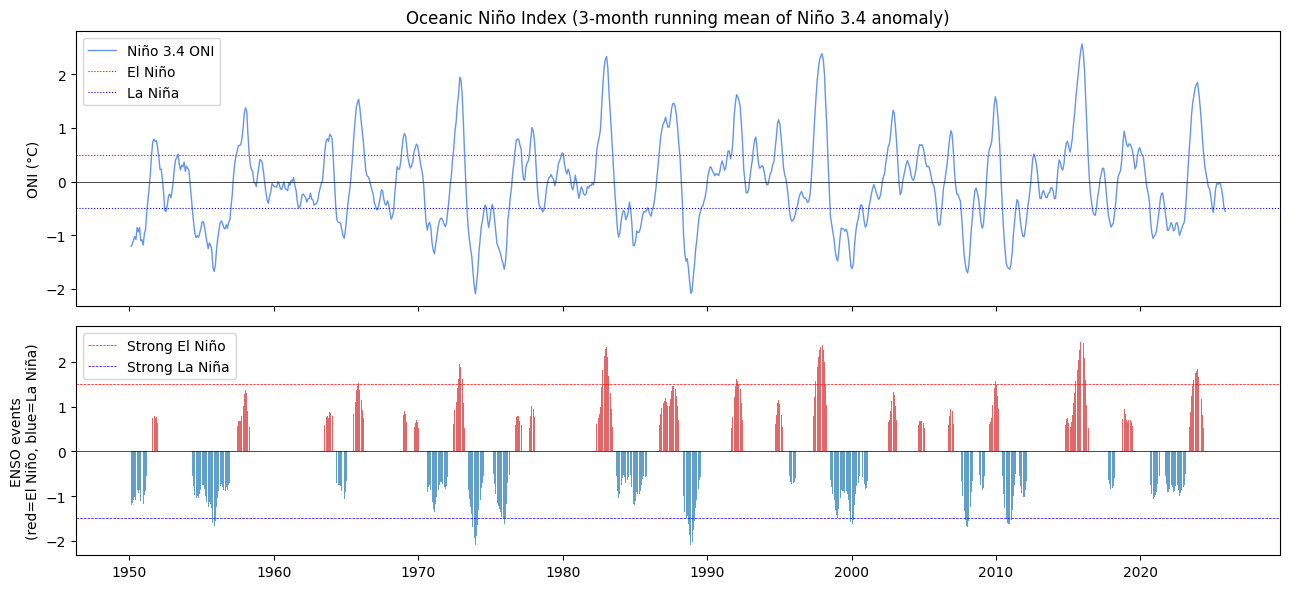

In [73]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                         gridspec_kw={"height_ratios": [1.2, 1]})
# 上：ONI 曲線 + 門檻
axes[0].plot(ssta.index, ssta["oni"], color="cornflowerblue", lw=1, label="Niño 3.4 ONI")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].axhline(0.5, color="red", ls=":", lw=0.8, label="El Niño")
axes[0].axhline(-0.5, color="blue", ls=":", lw=0.8, label="La Niña")
axes[0].set_ylabel("ONI (°C)")
axes[0].set_title("Oceanic Niño Index (3-month running mean of Niño 3.4 anomaly)")
axes[0].legend(loc='upper left')

# 下：把事件期間塗成長條 (紅=聖嬰, 藍=反聖嬰)
for _, ev in events.iterrows():
    color = "tab:red" if ev["phase"] == "El Niño" else "tab:blue"
    vals = ssta.loc[ev["start"]:ev["end"], "oni"]   # 直接用真實索引切片 (day=15)
    axes[1].bar(vals.index, vals.values, width=25, color=color, alpha=0.7)
axes[1].axhline(y=1.5, linestyle="--", linewidth=0.5, color="red", label="Strong El Niño")
axes[1].axhline(y=-1.5, linestyle="--", linewidth=0.5, color="blue", label="Strong La Niña")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_ylabel("ENSO events\n(red=El Niño, blue=La Niña)")
axes[1].xaxis.set_major_locator(mdates.YearLocator(10))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

#### Code-2.1 EX: 同時抓下並繪出 NOAA 提供的 SST anomaly 時間序列與利用 ODB MHW API 得到的時間序列

以下 code 提供各位回去練習，由於抓取的 ODB MHW API 資料量龐大 (超過30年)，就不在課堂中實際操作。

In [74]:

'''
# Fetch ODB MHW API data year by year for the specified region
def fetch_yearly_data(lon0, lat0, lon1, lat1, start_year, end_year):
    all_data = []
    for year in range(start_year, end_year + 1):
        start = f"{year}-01-01"
        end = f"{year}-12-31"
        print(f"Fetching data for {start} to {end}...")
        yearly_data = fetch_mhw_data(lon0, lat0, lon1, lat1, start, end)
        if yearly_data is not None:
            all_data.append(yearly_data)
    if all_data:
        return pd.concat(all_data, ignore_index=True)
    else:
        return None
'''        

'\n# Fetch ODB MHW API data year by year for the specified region\ndef fetch_yearly_data(lon0, lat0, lon1, lat1, start_year, end_year):\n    all_data = []\n    for year in range(start_year, end_year + 1):\n        start = f"{year}-01-01"\n        end = f"{year}-12-31"\n        print(f"Fetching data for {start} to {end}...")\n        yearly_data = fetch_mhw_data(lon0, lat0, lon1, lat1, start, end)\n        if yearly_data is not None:\n            all_data.append(yearly_data)\n    if all_data:\n        return pd.concat(all_data, ignore_index=True)\n    else:\n        return None\n'

In [75]:
'''
start_year, end_year = 1982, 2024  # Iterate year range to get MHW data
ylon0, ylat0, ylon1, ylat1 = -170, -5, -120, 5  # Niño 3.4 region
ydata = fetch_yearly_data(ylon0, ylat0, ylon1, ylat1, start_year, end_year)
ydata.to_csv(f"{DATA_DIR}/examples/nino34_mhw_1982-2024.csv", index=False) # This file may excceed 300MB, just too large to store in GitHub 
'''

'\nstart_year, end_year = 1982, 2024  # Iterate year range to get MHW data\nylon0, ylat0, ylon1, ylat1 = -170, -5, -120, 5  # Niño 3.4 region\nydata = fetch_yearly_data(ylon0, ylat0, ylon1, ylat1, start_year, end_year)\nydata.to_csv(f"{DATA_DIR}/examples/nino34_mhw_1982-2024.csv", index=False) # This file may excceed 300MB, just too large to store in GitHub \n'

In [76]:
# print(ydata.head())

In [77]:
'''
nino_mean = ydata.groupby("date")["sst_anomaly"].mean()
nino_mean.index = pd.to_datetime(nino_mean.index)
print(nino_mean.head())
print(len(nino_mean))
nino_mean.to_csv("./data/examples/nino34_mean_1982-2024.csv", index=True)

sst_mean = ydata.groupby("date")["sst"].mean()
sst_mean.index = pd.to_datetime(sst_mean.index)
print(sst_mean.head())
print(len(sst_mean))
sst_mean.to_csv("./data/examples/nino34_sst_1982-2024.csv", index=True)
'''
nino_mean  = pd.read_csv(f"{DATA_DIR}/examples/nino34_mean_1982-2024.csv", index_col=0, parse_dates=True)
print(nino_mean.head())

            sst_anomaly
date                   
1982-01-01     0.181876
1982-02-01    -0.139610
1982-03-01    -0.026869
1982-04-01     0.198018
1982-05-01     0.650803


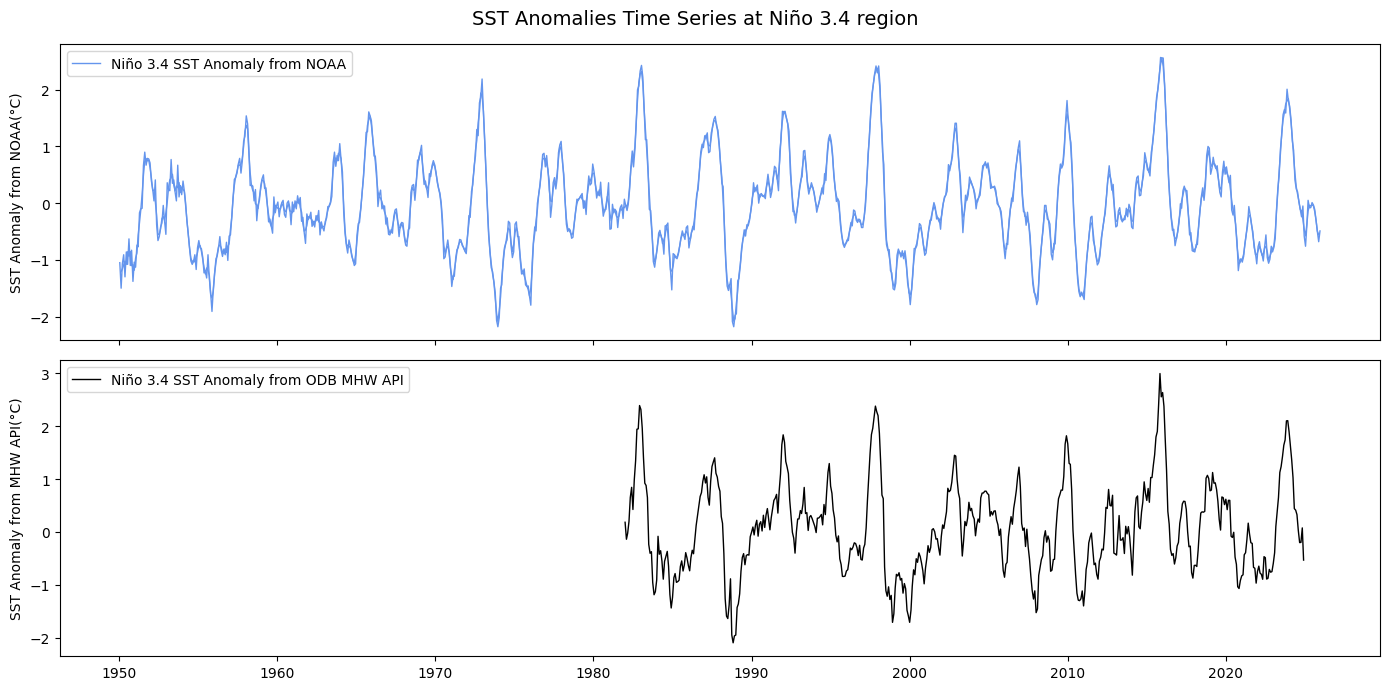

In [78]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Plot 1: Niño 3.4 SST anomaly
axes[0].plot(ssta.index, ssta, color='cornflowerblue', lw=1)
axes[0].set_ylabel("SST Anomaly from NOAA(°C)")
axes[0].legend(["Niño 3.4 SST Anomaly from NOAA"], loc='upper left')

# Plot 2: Data from ODB MHW API
axes[1].plot(nino_mean.index, nino_mean, color='black', lw=1)
axes[1].set_ylabel("SST Anomaly from MHW API(°C)")
axes[1].legend(["Niño 3.4 SST Anomaly from ODB MHW API"], loc='upper left')

plt.suptitle("SST Anomalies Time Series at Niño 3.4 region", fontsize=14)
fig.tight_layout()

# 此圖也是投影片 7 下半部結果，兩者在變動趨勢上是一致的，差異在於資料來源不同，NOAA 資料較為長期，ODB MHW API 提供 OISST 1982 之後的衛星高解析資料。

#### Code-2.1 結論

- 好的時間序列資料是"珍稀資源"，不易取得，尤其是非儀器自動觀測，或者早期的時間序列。
    ODB MHW API 提供超過 40 年的 OISST 資料，這是由衛星收集轉換而來的海洋資料。但若要分析更大尺度的長期變遷，比如可利用這一份 NOAA 提供在  Niño 3.4 區域的 1950~ SST anomaly 資料，結合了在 1982 之前，可能透過船舶、人工量測與歷史文件等紀錄，再經過後來的校正偏差所得到。在之後的時間序列分析當中，會發現像這樣扣除基期長期平均的數據，同時也會扣除不同基準的系統性偏誤，以及和季節變換共通的週期性等，有助於我們了解資料真正的變動。

- 但不管如何，時間序列愈長期，便愈複雜，背後混雜的因子愈多，而愈難分析。我們在這個單元提供一個有用的實作：將我們關心的時間序列中的 pattern，轉換為 **事件** 資料，這將有助於我們排除時間序列中複雜的連續性變動（而且常常是未知因子、非線性的），專注於影響這些事件/pattern 的真正原因。

#### Code-2.2 探討坦尚尼亞霍亂資料，與 ENSO 事件的時間序列的相關性
目標：
- 從前面的動畫當中，發現聖嬰帶來的雨季似乎伴隨著非洲部分地區霍亂事件的頻繁發生，我們將檢驗：它們之間是否真的存在相關性？
- 資料：SCI 文獻 Global Disease Outbreaks Associated with the 2015–2016 El Niño Event https://www.nature.com/articles/s41598-018-38034-z Fig.4-g

In [79]:
# Refer to https://www.nature.com/articles/s41598-018-38034-z
# Global Disease Outbreaks Associated with the 2015–2016 El Niño Event
# To digitize the Fig.4g and get data: https://github.com/cywhale/marineheatwave/bob/main/API/dev/examples/digitize_plot01.py
# Load the Tanzania cholera data
cholera = pd.read_csv(f'{DATA_DIR}/examples/tanzania_cholera_detrended.csv')
print(cholera) #It's yearly data!

    year  detrended_cholera_cases
0   2000             -2111.111111
1   2001             -5068.376068
2   2002              4801.975802
3   2003             -5337.218337
4   2004              3572.982573
5   2005             -3071.262071
6   2006              7451.992452
7   2007             -4069.819070
8   2008             -2764.013764
9   2009              1767.898768
10  2010             -1035.742036
11  2011             -4185.037185
12  2012             -4722.721723
13  2013             -4607.503608
14  2014             -4722.721723
15  2015              5838.938839
16  2016              5915.750916
17  2017               116.439116


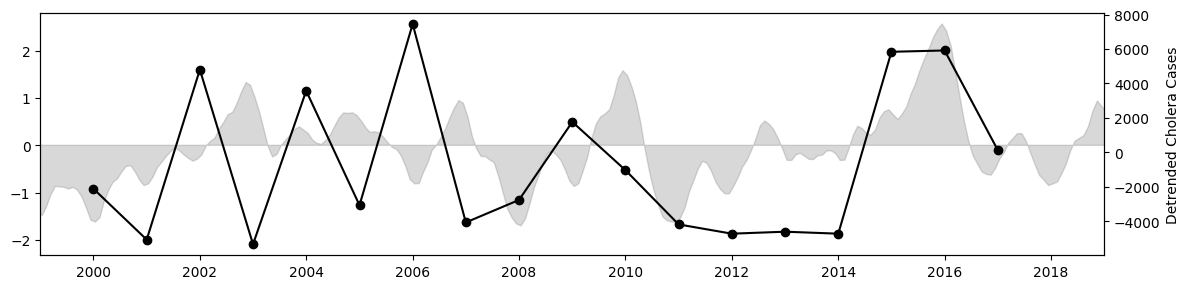

In [80]:
oni = ssta['ssta'].rolling(window=3, center=True).mean()

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 3))

# 1. Gray shaded full ONI curve
ax1.fill_between(oni.index, oni, 0, color='gray', alpha=0.3, label='ONI 3mo mean')

# 2. Cholera annual points at mid-year
ax2 = ax1.twinx()
cholera_dates = pd.to_datetime(cholera["year"].astype(str)) 
ax2.set_xlim(pd.Timestamp("1999-01-01"), pd.Timestamp("2018-12-31"))
ax2.plot(cholera_dates, cholera["detrended_cholera_cases"], 'ko-', label='Cholera Cases')
ax2.set_ylabel("Detrended Cholera Cases")
fig.tight_layout()

## 投影片 8 — El Niño and Disease Outbreaks

參照研究文獻原始圖 

![投影片 8: Ref paper Fig.4e-h](./lectures/ENSO_vs_cholera_outbreak_paper01.png)

- 該研究可以證實，在研究年間（2015/2016）的確有顯著較高的雨量分布 (Fig. 4f)，當聖嬰現象帶來持續且極端的強降雨與洪水時，會破壞當地的下水道與供水系統，導致飲用水源被污水和排泄物污染，有可能導致霍亂發生。
- 如果用前述的 SST Anomaly 來象徵聖嬰事件（Anomaly -> ONI -> ENSO），在研究文獻中疊合霍亂發生（Fig. 4g）match，但若我們同樣以此數據畫出上圖：
「說好的 match 呢？」
- 這裡我們已經看到一個時間序列分析的陷阱：兩個時間序列的時間精細度不同（SST anomaly: 月資料，霍亂事件：年資料），2016的霍亂數據，其實是一整年累積下來的總和，而不是在2016年初就全部發生。但就算平移後 pattern 很像，時間精細度不同，做兩條序列的相關性通常沒有意義，硬做甚至會導出謬誤。

In [81]:
# 將ENSO events簡化使用 ONI 指數發生在 Dec-Jan-Feb(DJF)月份代表該年為聖嬰年或反聖嬰年（或沒發生: Neutral）
def annual_enso_phase(ssta_df, years, assign_to_next_year):
    """
    把跨年的冬季 DJF (12–1–2 月) ONI 指派成「某一年 yr」的 ENSO 相位。
    以「2006-12 ~ 2007-02 的 ONI 突破門檻」這次聖嬰為例：

    assign_to_next_year=False（定義 A，一般慣例定義）:
        yr 的相位 = DJF(今年12月, 明年1月, 明年2月) → 2006 算聖嬰年
        （事件以「起始年」命名；把 2006 全年霍亂對上 2006 聖嬰）。
    assign_to_next_year=True （定義 B，為探討這個文獻範例故意做的人為定義，以影響年觀點來看）:
        yr 的相位 = DJF(去年12月, 今年1月, 今年2月) → 同一個 DJF 改算給 2007
        （聖嬰峰值在冬季，對降雨/公衛的衝擊多落在「隔年」，故對齊受影響的那一年）。
    """
    rows = []
    for yr in years:
        base = yr - 1 if assign_to_next_year else yr
        djf_months = [pd.Timestamp(base, 12, 15),
                      pd.Timestamp(base + 1, 1, 15),
                      pd.Timestamp(base + 1, 2, 15)]
        try:
            oni = ssta_df.loc[djf_months, "oni"].mean()
        except KeyError:
            oni = np.nan
        phase = ("El Niño" if oni >= 0.5 else "La Niña" if oni <= -0.5 else "Neutral")
        rows.append({"year": yr, "oni_djf": oni, "enso_phase": phase})
    return pd.DataFrame(rows)


In [82]:
df_A = annual_enso_phase(ssta, cholera["year"], False)
print(df_A.head())

df_B = annual_enso_phase(ssta, cholera["year"], True)
print(df_B.head())

   year   oni_djf enso_phase
0  2000 -0.774444    La Niña
1  2001 -0.167778    Neutral
2  2002  0.992222    El Niño
3  2003  0.227778    Neutral
4  2004  0.502222    El Niño
   year   oni_djf enso_phase
0  2000 -1.575556    La Niña
1  2001 -0.774444    La Niña
2  2002 -0.167778    Neutral
3  2003  0.992222    El Niño
4  2004  0.227778    Neutral


In [83]:
merged_A = cholera.merge(df_A, on="year", how="left")
merged_B = cholera.merge(df_B, on="year", how="left")
print(merged_A)

    year  detrended_cholera_cases   oni_djf enso_phase
0   2000             -2111.111111 -0.774444    La Niña
1   2001             -5068.376068 -0.167778    Neutral
2   2002              4801.975802  0.992222    El Niño
3   2003             -5337.218337  0.227778    Neutral
4   2004              3572.982573  0.502222    El Niño
5   2005             -3071.262071 -0.781111    La Niña
6   2006              7451.992452  0.560000    El Niño
7   2007             -4069.819070 -1.637778    La Niña
8   2008             -2764.013764 -0.812222    La Niña
9   2009              1767.898768  1.425556    El Niño
10  2010             -1035.742036 -1.492222    La Niña
11  2011             -4185.037185 -0.853333    La Niña
12  2012             -4722.721723 -0.236667    Neutral
13  2013             -4607.503608 -0.270000    Neutral
14  2014             -4722.721723  0.646667    El Niño
15  2015              5838.938839  2.354444    El Niño
16  2016              5915.750916 -0.308889    Neutral
17  2017  

A: DJF→that year -> {'El Niño': 3119.0, 'La Niña': -2446.0, 'Neutral': -2764.0}
Sample size:  enso_phase
El Niño    6
La Niña    7
Neutral    5
dtype: int64
B: DJF→next year -> {'El Niño': -293.0, 'La Niña': -1376.0, 'Neutral': -168.0}
Sample size:  enso_phase
El Niño    6
La Niña    7
Neutral    5
dtype: int64


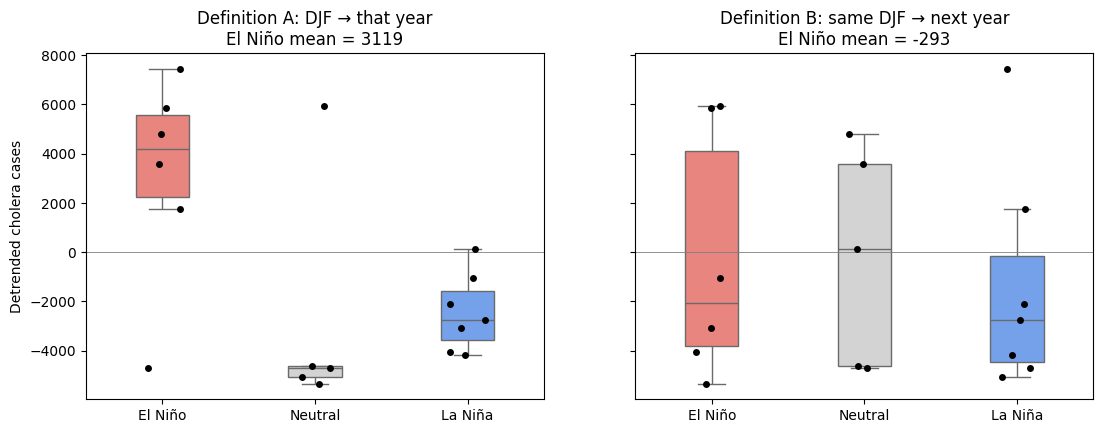

In [84]:
for label, mdf in [("A: DJF→that year", merged_A), ("B: DJF→next year", merged_B)]:
    means = mdf.groupby("enso_phase")["detrended_cholera_cases"].mean().round(0)
    print(label, "->", means.to_dict())
    print("Sample size: ", mdf.groupby('enso_phase').size())
    
order = ["El Niño", "Neutral", "La Niña"]
palette = {"El Niño": "#f8766d", "La Niña": "#619cff", "Neutral": "lightgray"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (mdf, title) in zip(
        axes, [(merged_A, "Definition A: DJF → that year"),
               (merged_B, "Definition B: same DJF → next year")]):
    sns.boxplot(data=mdf, x="enso_phase", y="detrended_cholera_cases", order=order,
                hue="enso_phase", palette=palette, legend=False,
                showfliers=False, width=0.35, ax=ax)
    sns.stripplot(data=mdf, x="enso_phase", y="detrended_cholera_cases", order=order,
                  color="black", jitter=0.12, ax=ax)
    means = mdf.groupby("enso_phase")["detrended_cholera_cases"].mean()
    ax.set_title(f"{title}\nEl Niño mean = {means.get('El Niño', float('nan')):.0f}")
    ax.set_xlabel(""); ax.axhline(0, color="gray", lw=0.6)
axes[0].set_ylabel("Detrended cholera cases")
# plt.suptitle("Same data, two reasonable definitions → opposite conclusions", y=0.99)
# plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

##### Code-2.2 EX: 將文獻資料取出，並畫出與 ENSO events 疊合的時間序列圖

以下 code 提供各位回去練習，不在課堂中實際操作。注意：我們刻意移動了坦尚尼亞霍亂事件（年）在每年的末段（10月），而非上一張圖每年的開始。

In [85]:
'''
def plot_cholera_vs_enso(cholera_df, nino_df, events_df):
    # import matplotlib.pyplot as plt
    # Prepare ONI 3-month moving average (masked/clean)
    oni = nino_df['ssta'].rolling(window=3, center=True).mean().dropna().astype(float)

    # Flatten ENSO events into monthly records for bar heights
    enso_long = []
    for _, row in events_df.iterrows():
        period = pd.date_range(start=row["start"], end=row["end"], freq="MS")
        for date in period:
            enso_long.append({"date": date.replace(day=15), "phase": row["phase"]})
    enso_long = pd.DataFrame(enso_long).set_index("date")
    enso_long = enso_long.join(nino_df["ssta"], how="left")

    # Determine colors and bar heights
    enso_colors = []
    enso_bar_values = []
    for _, row in enso_long.iterrows():
        val = row['ssta']
        if row['phase'] == "El Niño":
            enso_colors.append('#f8766d')
            enso_bar_values.append(val)
        elif row['phase'] == "La Niña":
            enso_colors.append('#619cff')
            enso_bar_values.append(val)
        else:
            # neutral — optional: lightgray or zero height
            enso_colors.append('lightgray')
            enso_bar_values.append(0)

    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 3))

    # 1. Gray shaded full ONI curve
    ax1.fill_between(oni.index, oni, 0, color='gray', alpha=0.3, label='ONI 3mo mean')

    # 2. Red/blue bars for ENSO months
    ax1.bar(enso_long.index, enso_bar_values, width=20, color=enso_colors, alpha=0.7, label='ENSO anomaly')

    # 3. Trick: Cholera annual points at end of the year (Oct, before DJF events)
    ax2 = ax1.twinx()
    cholera_dates = pd.to_datetime(cholera_df["year"].astype(str)) + pd.DateOffset(months=10, days=15)
    ax2.plot(cholera_dates, cholera_df["detrended_cholera_cases"], 'ko-', label='Cholera Cases')
    ax2.set_ylabel("Detrended Cholera Cases")

    # Labels, limits, legends
    ax1.set_ylabel("Niño 3.4 SSTA (°C)")
    ax1.set_xlim(pd.Timestamp("1999-01-01"), pd.Timestamp("2018-12-31"))
    ax1.set_title("Tanzania Cholera vs Monthly ONI & ENSO Anomalies (bars)")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()
'''

'\ndef plot_cholera_vs_enso(cholera_df, nino_df, events_df):\n    # import matplotlib.pyplot as plt\n    # Prepare ONI 3-month moving average (masked/clean)\n    oni = nino_df[\'ssta\'].rolling(window=3, center=True).mean().dropna().astype(float)\n\n    # Flatten ENSO events into monthly records for bar heights\n    enso_long = []\n    for _, row in events_df.iterrows():\n        period = pd.date_range(start=row["start"], end=row["end"], freq="MS")\n        for date in period:\n            enso_long.append({"date": date.replace(day=15), "phase": row["phase"]})\n    enso_long = pd.DataFrame(enso_long).set_index("date")\n    enso_long = enso_long.join(nino_df["ssta"], how="left")\n\n    # Determine colors and bar heights\n    enso_colors = []\n    enso_bar_values = []\n    for _, row in enso_long.iterrows():\n        val = row[\'ssta\']\n        if row[\'phase\'] == "El Niño":\n            enso_colors.append(\'#f8766d\')\n            enso_bar_values.append(val)\n        elif row[\'phase\

In [86]:
'''
plot_cholera_vs_enso(merged_A, ssta, events)
'''

'\nplot_cholera_vs_enso(merged_A, ssta, events)\n'

#### Code-2.2 結論 (投影片 8)

- 只是換了 DJF 指派給哪一年，聖嬰年的霍亂訊號的顯著性就從『明顯偏高』變成『幾乎沒差』！

- 時間序列轉化為適當的**事件**資料，常有助於統計分析，尤其面對非線性、不同時間規模或精細度的資料。
- 事件發生的**頻繁**與否、如何**分類**都可以著力，但須合理。
- 有相關性或顯著差別，並不能推演為具有**因果性（causality）**。


## 投影片 9 — Time-series Decomposition by STL

#### Code-3. 時間序列基礎 + STL 分解

目標：STL 分解：把序列拆成 趨勢 / 季節 / 殘差
- STL = Seasonal-Trend decomposition using LOESS (「局部加權散點平滑法」Locally Estimated Scatterplot Smoothing)。 
- 為何須了解時間序列中的趨勢、季節性與殘差（**residuals**）？
- **STL** 有何限制？

- 技巧：製造一個已知趨勢與季節性周期的訊號，再用 STL 拆解出藏在訊號中的趨勢與週期，來和已知答案驗證。


In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

In [88]:
def make_synthetic_series(n=120, freq="MS", start="2010-01-01",
                          slope=0.04, season_amp=2.0, noise=0.5,
                          base=20, seed=2026) -> pd.DataFrame:
    """
    回傳 DataFrame(index=日期)，欄位:
      - y      : 觀測 = 趨勢 + 季節 + 噪音
      - trend  : 趨勢 
      - season : 季節性週期
      - signal : 趨勢 + 季節 (無噪音)
    """
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    idx = pd.date_range(start, periods=n, freq=freq)
    trend = base + slope * t
    season = season_amp * np.sin(2 * np.pi * t / 12)
    e = noise * rng.standard_normal(n)
    return pd.DataFrame(
        {"y": trend + season + e, "trend": trend, "season": season,
         "signal": trend + season},
        index=idx,
    )

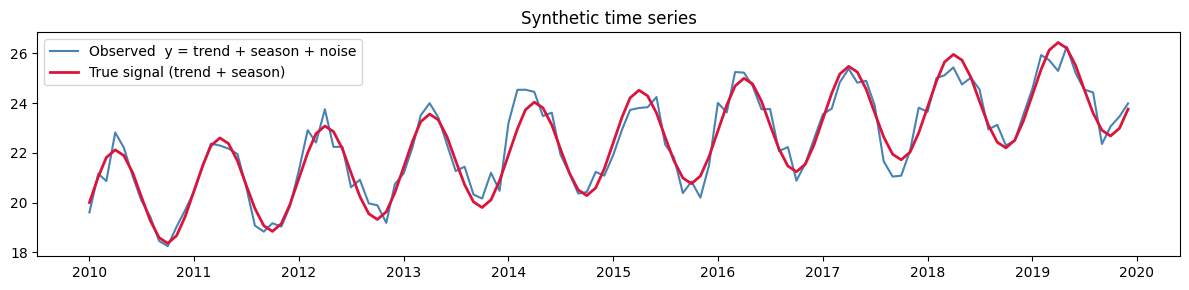

In [89]:
sim = make_synthetic_series(n=120, slope=0.04, season_amp=2.0, noise=0.5)

plt.figure(figsize=(12, 3))
plt.plot(sim.index, sim["y"], label="Observed  y = trend + season + noise", color="steelblue")
plt.plot(sim.index, sim["signal"], label="True signal (trend + season)", color="crimson", lw=2)
plt.title("Synthetic time series")
plt.legend()
plt.tight_layout()
plt.show()

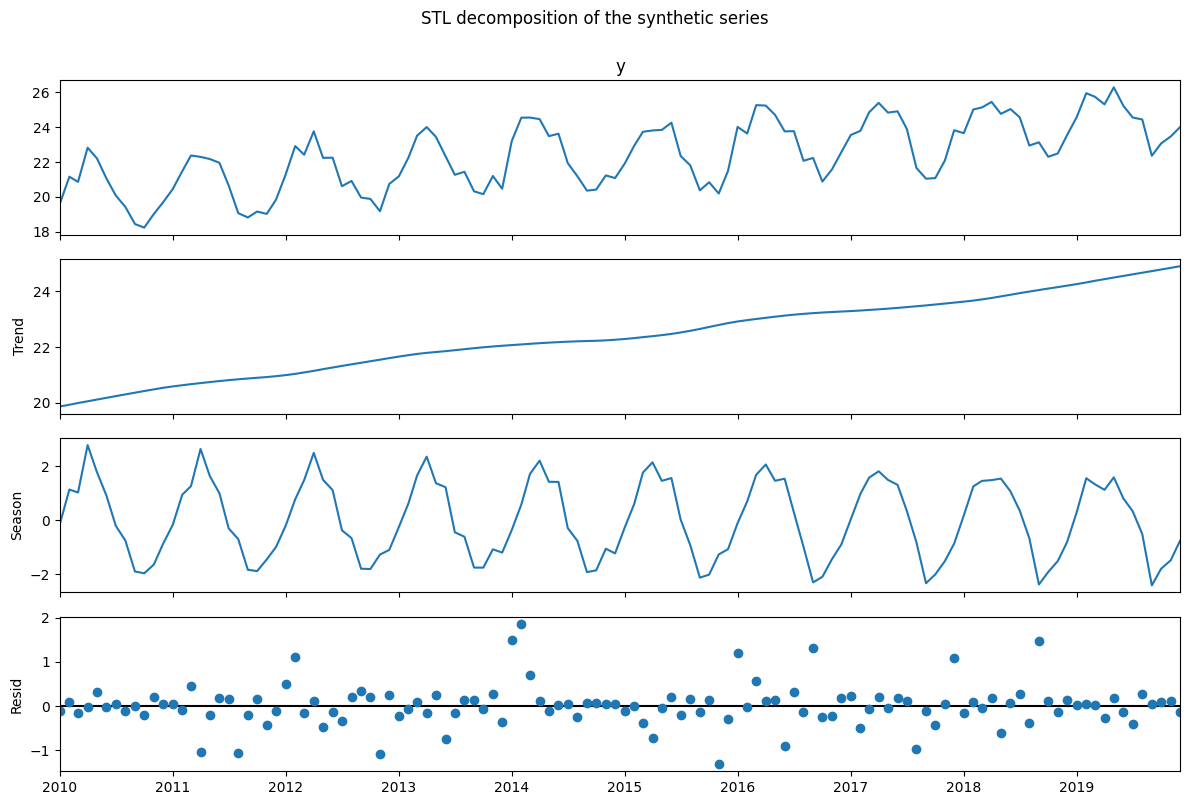

In [90]:
# 參數: `period=12` 表示一年 12 個月。`robust=True` 會降低離群值 (outlier) 的權重，讓擬合(fit)的過程不易因極端值失真。
stl_sim = STL(sim["y"], period=12, robust=True).fit()
fig = stl_sim.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL decomposition of the synthetic series", y=1.00)
plt.tight_layout()
plt.show()

#### Code-3.1 EX：驗證 STL 拆出來的趨勢/季節，是否接近我們設定的真值？
把 STL 的 trend、seasonal 疊回造資料時的 ground truth（真實趨勢與真實週期）。

In [91]:
'''
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(sim.index, sim["trend"], label="True trend", color="crimson", lw=2)
axes[0].plot(sim.index, stl_sim.trend, label="STL-estimated trend", color="black", ls="--")
axes[0].set_title("Trend")
axes[0].legend(loc="upper left")

axes[1].plot(sim.index, sim["season"], label="True seasonal", color="crimson", lw=2)
axes[1].plot(sim.index, stl_sim.seasonal, label="STL-estimated seasonal", color="black", ls="--")
axes[1].set_title("Seasonal")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()
'''

'\nfig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)\naxes[0].plot(sim.index, sim["trend"], label="True trend", color="crimson", lw=2)\naxes[0].plot(sim.index, stl_sim.trend, label="STL-estimated trend", color="black", ls="--")\naxes[0].set_title("Trend")\naxes[0].legend(loc="upper left")\n\naxes[1].plot(sim.index, sim["season"], label="True seasonal", color="crimson", lw=2)\naxes[1].plot(sim.index, stl_sim.seasonal, label="STL-estimated seasonal", color="black", ls="--")\naxes[1].set_title("Seasonal")\naxes[1].legend(loc="upper left")\nplt.tight_layout()\nplt.show()\n'

#### Code 3.2 用 STL 拆解真實時間序列資料：原始海溫之殘差 vs 距平值
利用前面 ODB MHW API 換上真的海洋資料：**Niño 3.4 區域月平均海溫**（赤道中太平洋，判斷聖嬰/反聖嬰的關鍵區）。

- 距平 = 原始 − 月氣候平均。當這樣把基準拉到 0 之後，和一條訊號（時間序列）減去 STL 長期趨勢與週期，即所謂的 Noise，會有近似的結果。而在這可打破先入觀念，Noise其實不只是字義上的噪音，而仍帶有可代表此時間序列特性的重要訊息，可供解讀。

In [92]:
# ---------------------------------------------------------------------------
# 2. Niño 3.4 區域平均 SST / 距平 (由 ODB MHW API 預先彙整，存成本機 CSV)
# ---------------------------------------------------------------------------
def load_nino34_sst() -> pd.Series:
    """Niño 3.4 區域月平均「原始」海表溫 (含季節循環)。index=date。"""
    df = pd.read_csv(DATA_DIR / "examples/nino34_sst_1982-2024.csv",
                     index_col=0, parse_dates=True)
    return df["sst"]

sst = load_nino34_sst()
print(sst.head())

date
1982-01-01    26.583525
1982-02-01    26.455039
1982-03-01    27.034319
1982-04-01    27.782716
1982-05-01    28.324911
Name: sst, dtype: float64


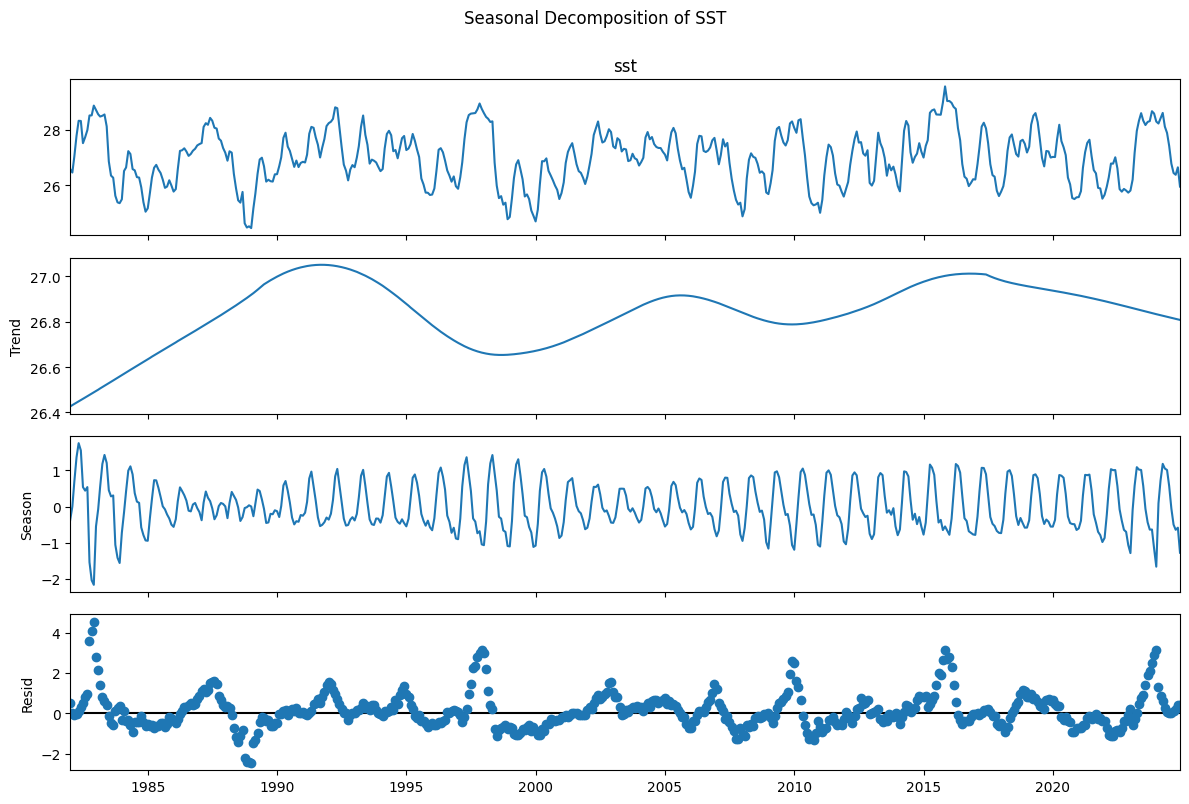

In [93]:
# 練習：拿掉或加入參數 trend=181, 180/12 = 15 (年)，把 trend window 減短/拉長，看看對趨勢預測的影響
# 設成奇數 (e.g., 181) 是因為在 fit 過程中的移動窗口，奇數可以對稱地取在中心點。
stl_sst = STL(sst, period=12, trend=181, robust=True).fit() 
fig = stl_sst.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f"Seasonal Decomposition of SST", y=1.00)
plt.tight_layout()

In [94]:
def monthly_climatology(series: pd.Series, base=("1982", "2011")) -> pd.Series:
    """
    由一段「基準期 (climatology base period)」算 12 個月的長期月平均。
    回傳 index 為月份 (1..12) 的 Series。
    """
    base_slice = series.loc[base[0]:base[1]] #Pandas 在處理以 datetime 為 index 的 Dataframe 時，會自動用部分字串匹配時間/日期格式 "1982":"2021" 會匹配到 1982-01-01 ~ 2021-12-31 的所有資料   
    return base_slice.groupby(base_slice.index.month).mean()

def to_anomaly(series: pd.Series, clim: pd.Series | None = None,
               base=("1982", "2011")) -> pd.Series:
    """把原始序列轉成距平：每個月減掉它所屬月份的長期平均。"""
    if clim is None:
        clim = monthly_climatology(series, base=base)
    return series - series.index.month.map(clim)

clim = monthly_climatology(sst, base=("1982", "2011"))   # 12 個月長期平均
print(clim)

baseline = sst.index.month.map(clim)  # 把月平均「鋪」回時間軸
print(baseline[0:11])

date
1     26.401649
2     26.594648
3     27.061189
4     27.584698
5     27.674108
6     27.474884
7     27.093275
8     26.750179
9     26.642719
10    26.573505
11    26.568917
12    26.481797
Name: sst, dtype: float64
Index([26.401649032592776, 26.594648477109274,  27.06118946781953,
       27.584697781729698, 27.674108416652683, 27.474883562644322,
       27.093275295853616,  26.75017862320741, 26.642718978174525,
        26.57350510002772,  26.56891706178188],
      dtype='float64', name='date')


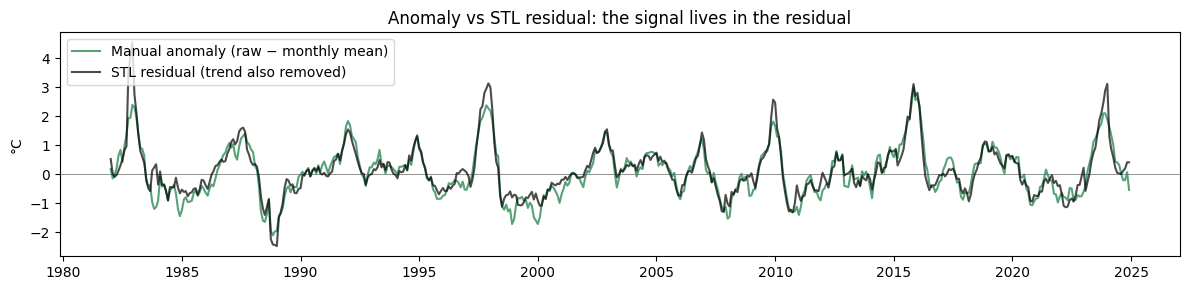

In [95]:
anom = to_anomaly(sst, clim)  # Niño 3.4 區域月平均海溫距平值

# 把「手算距平」與「STL 殘差」疊起來看：兩者形狀相近
plt.figure(figsize=(12, 3))
plt.axhline(0, color="gray", lw=0.6)
plt.plot(anom.index, anom, label="Manual anomaly (raw − monthly mean)", color="seagreen", alpha=0.8)
plt.plot(sst.index, stl_sst.resid, label="STL residual (trend also removed)", color="black", alpha=0.7)
plt.title("Anomaly vs STL residual: the signal lives in the residual")
plt.ylabel("°C")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### Code-3.2 EX：畫出 Niño 3.4 SST、周期性與距平值 

用 Niño 3.4 區域 SST 資料，疊合其週期性（STL 可提供）並同時與距平值比較，觀察它們的變化幅度。

In [96]:
'''
print("Note: 季節 (climatology) 全年振幅僅 %.2f°C，原始值跨度卻有 %.2f°C"
      % (clim.max() - clim.min(), sst.max() - sst.min()))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(sst.index, sst, color="darkorange", lw=1, label="Raw SST")
axes[0].plot(sst.index, baseline, color="gray", ls="--", lw=1.2,
             label="Monthly climatology (1982–2011)")
axes[0].set_title("Niño 3.4 raw SST vs monthly climatology  (season is weak near the equator)")
axes[0].set_ylabel("SST (°C)")
axes[0].legend(loc="upper left")

axes[1].axhline(0, color="gray", lw=0.6)
axes[1].fill_between(anom.index, anom, 0, where=anom >= 0, color="tab:red", alpha=0.5)
axes[1].fill_between(anom.index, anom, 0, where=anom < 0, color="tab:blue", alpha=0.5)
axes[1].axhline(0.5, color="red", ls=":", lw=0.8)
axes[1].axhline(-0.5, color="blue", ls=":", lw=0.8)
axes[1].set_title("Anomaly = raw − monthly climatology   (±0.5°C dotted = ENSO threshold, next section)")
axes[1].set_ylabel("SST anomaly (°C)")
plt.tight_layout()
plt.show()

'''

'\nprint("Note: 季節 (climatology) 全年振幅僅 %.2f°C，原始值跨度卻有 %.2f°C"\n      % (clim.max() - clim.min(), sst.max() - sst.min()))\n\nfig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)\naxes[0].plot(sst.index, sst, color="darkorange", lw=1, label="Raw SST")\naxes[0].plot(sst.index, baseline, color="gray", ls="--", lw=1.2,\n             label="Monthly climatology (1982–2011)")\naxes[0].set_title("Niño 3.4 raw SST vs monthly climatology  (season is weak near the equator)")\naxes[0].set_ylabel("SST (°C)")\naxes[0].legend(loc="upper left")\n\naxes[1].axhline(0, color="gray", lw=0.6)\naxes[1].fill_between(anom.index, anom, 0, where=anom >= 0, color="tab:red", alpha=0.5)\naxes[1].fill_between(anom.index, anom, 0, where=anom < 0, color="tab:blue", alpha=0.5)\naxes[1].axhline(0.5, color="red", ls=":", lw=0.8)\naxes[1].axhline(-0.5, color="blue", ls=":", lw=0.8)\naxes[1].set_title("Anomaly = raw − monthly climatology   (±0.5°C dotted = ENSO threshold, next section)")\naxes[1].set_ylabel("SST an

#### Code-3 結論 

- 你可以看到，赤道周遭的季節性變化幅度很小。此圖重複上面的發現：距平值 Anomaly（減去每月氣候平均值，包括它的週期變化後）仍帶有可代表此時間序列特性的重要訊息。訊號中的周期性、趨勢往往由系統性的物理過程所驅動，比如太陽輻射、洋流等，長期趨勢也可能被全球暖化這種超大尺度的變化所影響。當我們把訊號扣除周期性和趨勢之後，剩下的殘差，純粹是由別的(較小尺度的)因子所驅動，而較為容易發掘裡面是否可能涵蓋我們想要探討的因子。
- 主軸：**訊號常藏在「殘差／距平」裡，而不是原始序列。** 這個觀念會在不同尺度案例中出現。
- STL的限制：真實世界的振盪很少是純正弦波（單一週期），而是調幅調頻的複合式振盪 + 隨機變數，因此你拆解出來的週期性，可能還是帶有複數以上的週期波疊合在裏頭，而無法被細分。即便是長期趨勢，雖然可以透過 `trend=` 調整，還是可能帶有長時間週期性在裏頭；同理，殘差 residual 裏頭，也可能帶有高頻的週期沒有被拆解，這要透過統計上的自相關（Autocorrelation，進階課程不屬本次範圍）來檢測；同樣，也有進階的拆解技術，比如 **EEMD**: Ensemble empirical mode decomposition 可突破 STL 限制。 


## 投影片 10 — 海氣象浮標資料處理

- 海氣象浮標為連續觀測之時間序列資料，處理上需注意缺值、離群值與在時間尺度上的處理。從不同的資料變數月平均可知具有明顯的季節性耦合，尤其是複合性的週期訊號，在處理相關性分析也須留意。


#### Code-4. 龍洞海氣象浮標 + STL + 湧升指數

- 資料：中央氣象署（CWA, 資料中則常用舊名 CWB）的龍洞浮標（由國海院 NAMR 取得）資料。利用前面所學的分析來看海氣象浮標的時間序列資料：
1. 觀察海氣象浮標浮標的時間序列特性
2. 重用 **STL** 取季節/趨勢/殘差
3. 參考文獻由原始風資料算出物理量「**湧升指數 (Upwelling Index)**」
4. 湧升指數 UI 和環境因子的相關性 V.S. SST


In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from statsmodels.tsa.seasonal import STL

from pathlib import Path
from typing import List
import warnings

#### Code-4.1 觀察海氣象浮標浮標的時間序列特性

In [98]:
# ------------------------------------------------------------------
# 1. Helpers to ingest local Taiwan‑CWA buoy files
# ------------------------------------------------------------------
CWA_SITES = {
    "Longdong": (25.0969, 121.9222),
    # "Hualien":  (24.0311, 121.6325),
    # "Hsinchu":  (24.7625, 120.8422),
    # "LiuqiuIsland": (22.3131, 120.3639),
}

VARIABLE_META = {
    "Hs": {
        "cwa_col": "示性波高",
        "label": "Significant wave height",
        "unit": "m"
    },
    "Wind": {
        "cwa_col": "風速",
        "label": "Wind speed",
        "unit": "m/s"
    },
    "Wind_Dir": {
        "cwa_col": "風向",
        "label": "Wind direction",
        "unit": "degree"
    },
    "SST": {
        "cwa_col": "海面溫度",
        "label": "Sea surface temperature",
        "unit": "°C"
    },
    # Add more if needed
}

Buoy_Target = f"{DATA_DIR}/buoy/testing"  # edit to actual root if needed: rawdata (CWA raw data); testing (3 days of data for testing).

In [99]:
CWA_ROOT = Path(Buoy_Target) 
CWA_TIME_COL = "時間" 
# 由於 CWQ 浮標資料欄位使用中文，不利於後續分析，故會選擇部份我們要的欄位，改成英文名稱，以利後續分析。

def read_cwa_site(site: str, years: range | List[int] = range(2010, 2025)) -> pd.DataFrame:
    frames: List[pd.DataFrame] = []
    site_dir = CWA_ROOT / site

    for y in years:
        f = site_dir / f"{y}.csv"
        if not f.exists():
            warnings.warn(f"missing file {f}")
            continue
        df = pd.read_csv(f, skiprows=[1, 2], low_memory=False)
        df = df.rename(columns={CWA_TIME_COL: "time"})

        # Standardize names
        for std_name, meta in VARIABLE_META.items():
            if meta["cwa_col"] in df.columns:
                df = df.rename(columns={meta["cwa_col"]: std_name})

        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df = df.dropna(subset=["time"]).set_index("time")
        df["site"] = site
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No CSV files found for {site}")
    return pd.concat(frames).sort_index()
    

In [100]:
start_year = 2024 if "testing" in Buoy_Target else 2010
cwa_sites = [read_cwa_site(site, years=range(start_year, 2025)) for site in CWA_SITES]
cwa_sites_df = pd.concat(cwa_sites).sort_index()
print(cwa_sites_df.head())


                                    測站編號  陣風_風速  Wind  Wind_Dir  氣壓  氣溫   SST  \
time                                                                            
2024-01-01 00:00:00  Vector_CWB_TG_C4A02    NaN   NaN       NaN NaN NaN  18.6   
2024-01-01 00:06:00  Vector_CWB_TG_C4A02    NaN   NaN       NaN NaN NaN  18.6   
2024-01-01 00:12:00  Vector_CWB_TG_C4A02    NaN   NaN       NaN NaN NaN  18.6   
2024-01-01 00:18:00  Vector_CWB_TG_C4A02    NaN   NaN       NaN NaN NaN  18.6   
2024-01-01 00:24:00  Vector_CWB_TG_C4A02    NaN   NaN       NaN NaN NaN  18.6   

                     Hs  平均週期  波向  波浪尖峰週期  流速  分層流速{深度:流速}  流向  分層流向{深度:流向}  \
time                                                                          
2024-01-01 00:00:00 NaN   NaN NaN     NaN NaN          NaN NaN          NaN   
2024-01-01 00:06:00 NaN   NaN NaN     NaN NaN          NaN NaN          NaN   
2024-01-01 00:12:00 NaN   NaN NaN     NaN NaN          NaN NaN          NaN   
2024-01-01 00:18:00 NaN   NaN NaN    

In [101]:
Target_site = list(CWA_SITES.keys())[0]
Target_Output = f"{DATA_DIR}/buoy/cwa_buoy_{Target_site}_2010-2024.csv"

if "testing" not in Buoy_Target:  
  '''
  print(len(cwa_sites_df))
  cwa_sites_df.to_csv(Target_Output, index=True)
  '''
else:
  print("In testing mode. Only for testing, do not overwrite the real data file.")

cwa_sites_df = pd.read_csv(Target_Output, index_col=0, parse_dates=True)
print(cwa_sites_df.head())

In testing mode. Only for testing, do not overwrite the real data file.
                         site  Wind  Wind_Dir   SST    Hs
time                                                     
2010-01-01 00:00:00  Longdong   4.6      65.0  18.1  1.50
2010-01-01 01:00:00  Longdong   4.3      69.0  18.1  1.83
2010-01-01 02:00:00  Longdong   4.9      78.0  18.1  2.07
2010-01-01 03:00:00  Longdong   4.7      64.0  18.0  2.13
2010-01-01 04:00:00  Longdong   4.7      67.0  18.2  2.32


In [102]:
def load_buoy(site="Longdong") -> pd.DataFrame:
    """龍洞浮標時頻資料 (欄位 site, Wind, Wind_Dir, SST, Hs), index 為 datetime"""
    df = pd.read_csv(DATA_DIR / f"buoy/cwa_buoy_{site}_2010-2024.csv",
                     index_col=0, parse_dates=True)
    return df[df["site"] == site] if "site" in df.columns else df

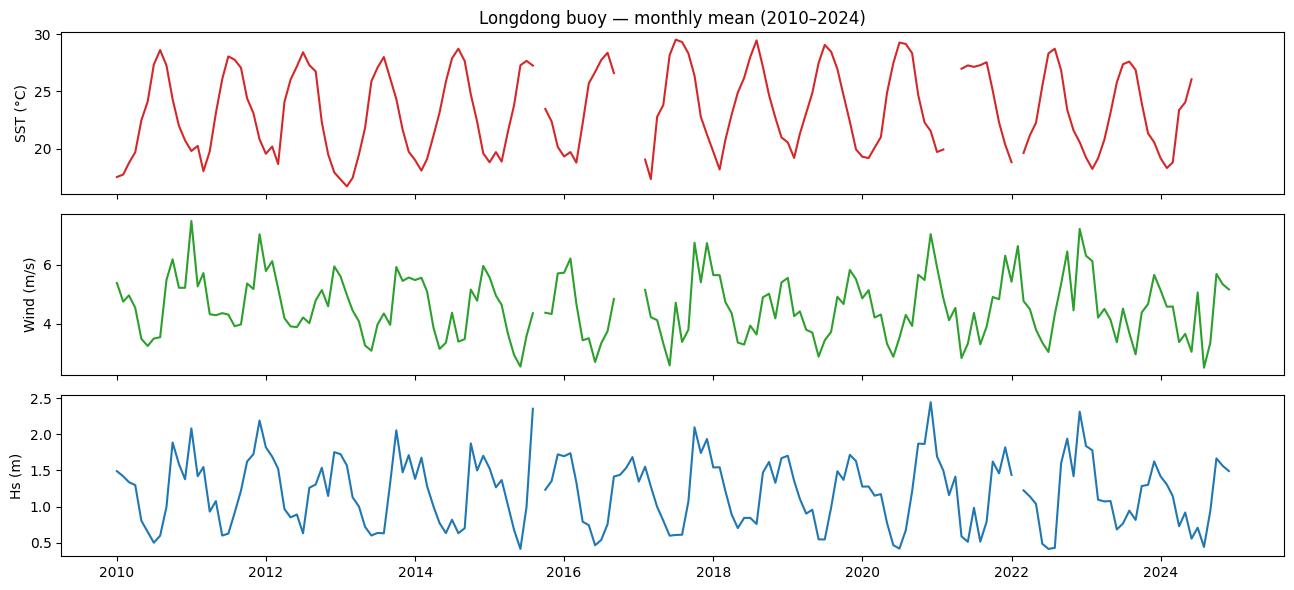

In [103]:
buoy = load_buoy("Longdong")
monthly = buoy[["SST", "Wind", "Hs"]].resample("MS").mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True)
axes[0].plot(monthly.index, monthly["SST"], color="tab:red"); axes[0].set_ylabel("SST (°C)")
axes[1].plot(monthly.index, monthly["Wind"], color="tab:green"); axes[1].set_ylabel("Wind (m/s)")
axes[2].plot(monthly.index, monthly["Hs"], color="tab:blue"); axes[2].set_ylabel("Hs (m)")
axes[0].set_title("Longdong buoy — monthly mean (2010–2024)")
plt.tight_layout()
plt.show()

#### Code-4.2 使用 STL 分析浮標資料中的水文環境因子，以 SST 為例
把日平均 SST 丟給 STL（`period=365`），可看到這裡 seasonal 振幅很大。

⚠️ 看 trend：它**不是**單調暖化、而是上下起伏。因為這裡**沒有鎖 `trend=`**，可能包含了「年代際的緩慢振盪」。這再次強調了所謂"週期性"，不會只有單一週期，而可能包含了多種週期的組合，而長周期的變化很容易被 STL 算進了趨勢——這是 STL 固定週期分解的侷限。
另外注意，殘差（residual）裡的一些大幅度震盪很可能只是**資料缺口**造成的插值假影。

正因如此，待會做湧升指數與環境因子比較時，SST 這個因子我們**不用這條 STL 殘差、改用「距平值」**
另外，你也會發現，各種因子：SST, Wind, Hs...的周期性其實強烈耦合在一起，所以這也呼應我們之前說週期性的背後往往是一個共通的系統性物理過程在驅動，所以要先將這個強烈的共同（耦合）因子扣除之後，你才容易看到，其他因子真正造成的影響。要不然，你永遠都會看到各個因子之間存在強烈的相關性。

In [104]:
def to_daily(series: pd.Series, min_hours=12) -> pd.Series:
    """
    時頻序列 → 日平均。當日有效值不足 min_hours 小時就整天捨棄。

    為什麼要「數點數」而不是先做移動平均？
    做移動平均雖然也能擋掉稀疏日，但它同時把訊號抹平 e.g: `rolling(48).resample("D")`
    的等效濾波其實跨 3 天 (48h 方波 ⊛ 24h 方波 = 72h 梯形)，過度平滑化會鈍化湧升事件的尖峰或抹消某些變化。
    """
    agg = series.resample("D").agg(["mean", "count"])
    return agg.loc[agg["count"] >= min_hours, "mean"].rename(series.name)

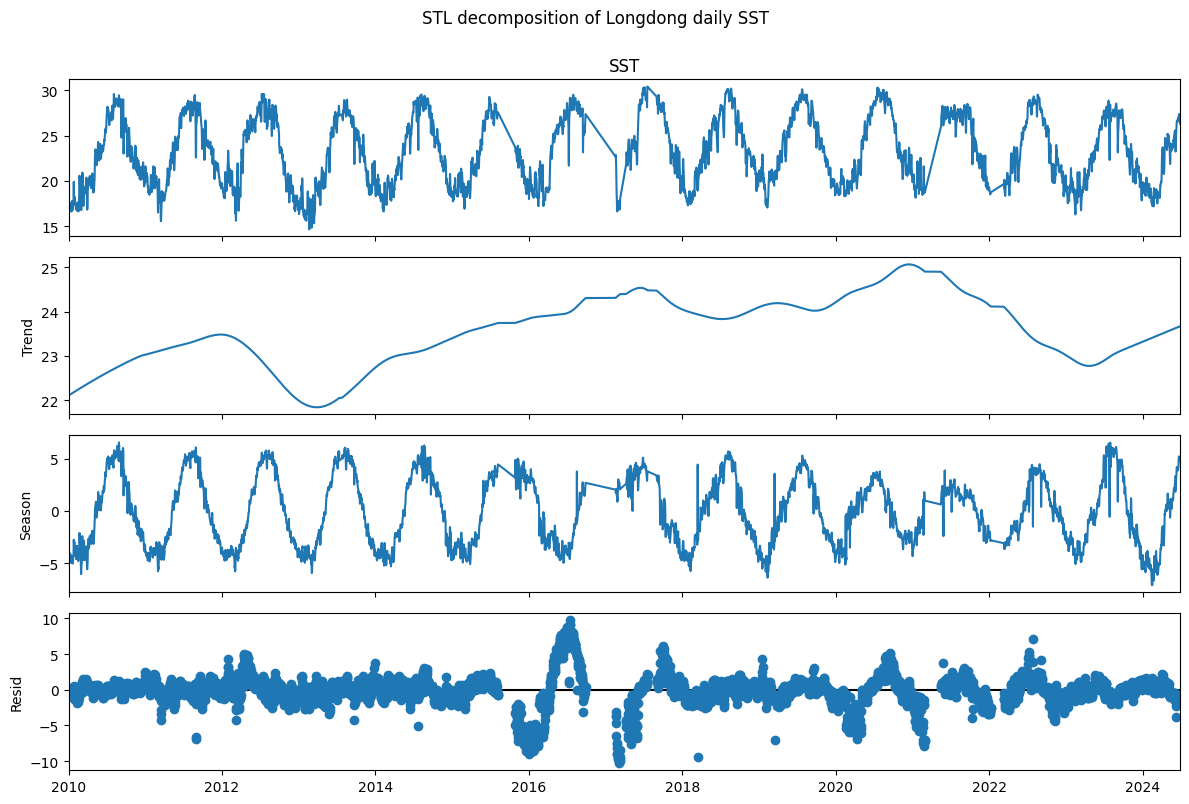

In [105]:
sst_d = to_daily(buoy["SST"].interpolate(limit=6),  # 補小缺口 (≤6 小時)
                min_hours=12)                       # 日平均，當日不足 12 小時就捨棄

stl_sst = STL(sst_d, period=365, robust=True).fit()
fig = stl_sst.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL decomposition of Longdong daily SST", y=1.00)
plt.tight_layout()
plt.show()

## 投影片 10 — 海氣象浮標資料：由風速、風向計算湧升指數

#### Code-4.3 由文獻提供的算式將原始風資料轉成「湧升指數 (Upwelling Index, UI)」
這是把**原始觀測值**變成**物理量**的好例子：
風速 + 風向 → 風應力沿岸分量 → 除以 (海水密度 × 科氏參數) → 離岸 Ekman 輸送。
**UI 為正 = 有利湧升**（把底層冷水帶上來）。公式見 Huang et al. 2021。

In [106]:
# Calculate Upwelling index (UI) 湧升指數
# Reference Paper: Huang et al. 2021. Mapping the Coastal Upwelling East of Taiwan Using Geostationary Satellite Data.
# https://www.mdpi.com/2072-4292/13/2/170

# 物理常數 (Huang et al. 2021)
_RHO_AIR = 1.22     # 空氣密度 kg/m^3
_RHO_W = 1026.0     # 海水密度 kg/m^3

def _drag_coef(V):  # drag coefficient 風阻力係數 Cd 的經驗公式 (Huang et al. 2021)
    return (0.8 + 0.065 * V) * 1e-3

def upwelling_index(df, site="Longdong", coast_angle=18.0) -> pd.Series:
    """
    由浮標風速/風向算「湧升指數」UI (m^2/s)：風應力沿岸分量 / (海水密度 × 科氏參數)。
    UI 為正 = 離岸 Ekman 輸送 = 有利湧升 (把底層冷水帶上來)。

    公式完全依 Huang et al. 2021 (Remote Sensing 13:170) eq 1–4：
        UI = ρa·Cd·V²·cos(α−β) / (f·ρw),  Cd=(0.8+0.065V)×1e-3,
        f = 2ω·sin(φ),  ρa=1.22, ρw=1026, ω=7.2921e-5
    論文岸線角 β：北段 18°、中段 15°、南段 20°（龍洞屬北段 → 18°）。

    Parameters
    ----------
    df : 含欄位 'Wind'(m/s)、'Wind_Dir'(度, 風『來向』: direction-from) 的 DataFrame
    site: 浮標所屬站點名稱，會自動帶入 CWB_SITES 對應的緯度
    coast_angle : 岸線走向 β (度, 自真北順時針；例：文獻中台灣東部海域北段≈18°)
    """
    lat = CWA_SITES[site][0]
    V = df["Wind"]
    alpha = (df["Wind_Dir"] + 180.0) % 360.0            # 風來向 → 風去向
    cos_ab = np.cos(np.deg2rad(alpha - coast_angle))    # 投影到離岸方向 cos(α−β) is the projection vector of τ: wind stess
    tau = _RHO_AIR * _drag_coef(V) * V ** 2 * cos_ab    # 風應力沿岸分量 τ: wind stess · cos(α−β)
    f = 2 * 7.2921e-5 * np.sin(np.deg2rad(lat))         # 科氏參數 Coriolis parameter (s⁻¹)
    return tau / (_RHO_W * f)                           # Upwelling index (m²/s)

In [107]:
wind = buoy[["Wind", "Wind_Dir"]].interpolate(limit=6)   # 只內插數值欄
ui_h = upwelling_index(wind, "Longdong", coast_angle=18.0)
ui_d = to_daily(ui_h, min_hours=12)  

print(ui_d.head())

time
2010-01-01   -0.014369
2010-01-02   -0.501080
2010-01-03   -0.488653
2010-01-04   -0.379373
2010-01-05   -1.515273
dtype: float64


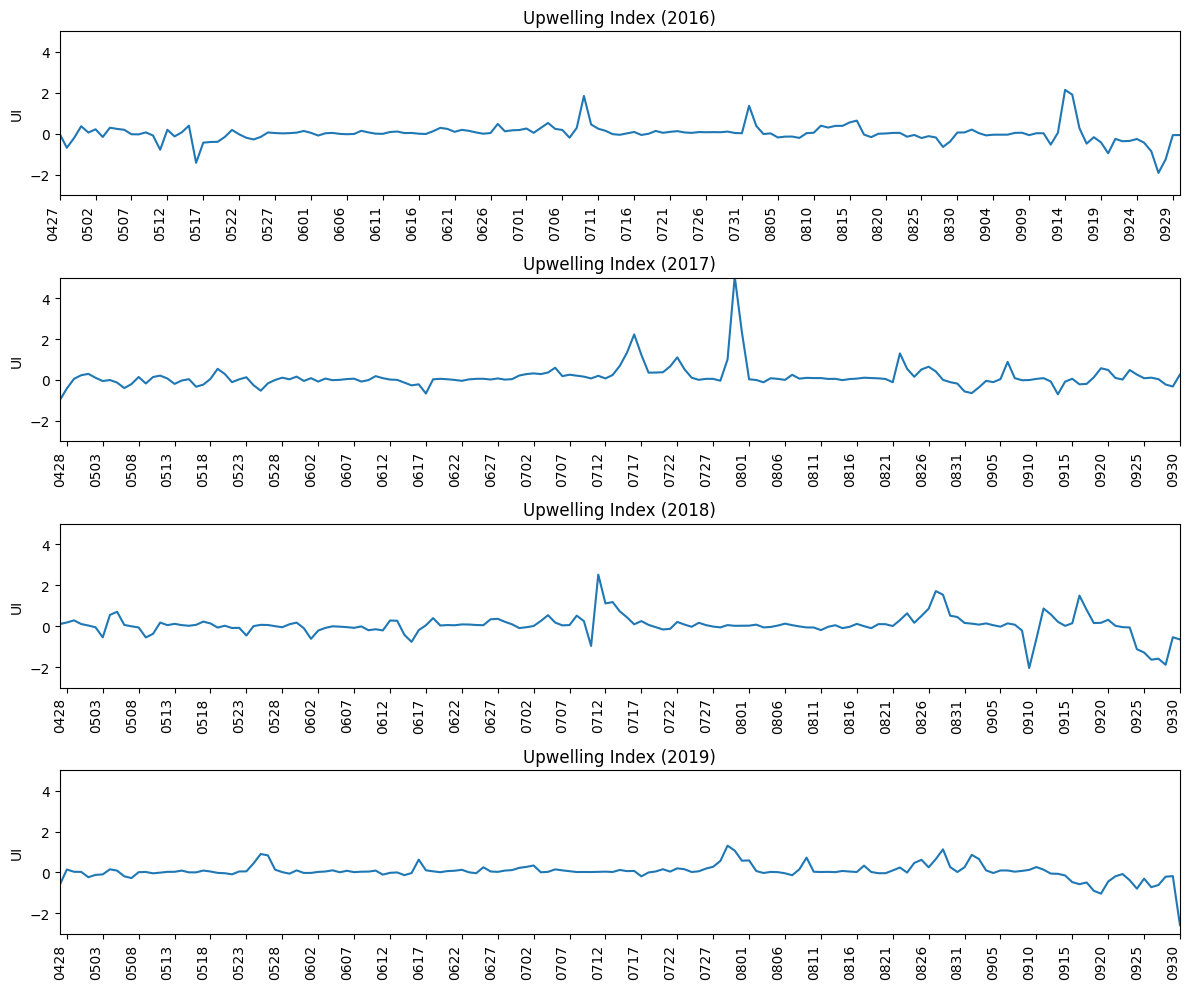

In [108]:
# Compare to Huang et al., 2021 Fig.3
# 時間範圍設定（可根據實際需要調整或擴充）
periods = {
    "2016": ("2016-04-27", "2016-09-30"),
    "2017": ("2017-04-27", "2017-09-30"),
    "2018": ("2018-04-27", "2018-09-30"),
    "2019": ("2019-04-27", "2019-09-30"),
}

# 動態建立 subplot，根據有幾個年份來建立幾個 subplot
fig, axes = plt.subplots(len(periods), 1, figsize=(12, 2.5 * len(periods)), sharey=True)

# 如果只有一個子圖，axes 不會是 list，需要統一格式
if len(periods) == 1:
    axes = [axes]

# 畫圖迴圈
for ax, (year, (start, end)) in zip(axes, periods.items()):
    ax.plot(ui_d.index, ui_d, label="Upwelling index (UI)", color="tab:blue")
    ax.set_title(f"Upwelling Index ({year})")
    ax.set_ylabel("UI")
    ax.set_xlim(pd.Timestamp(start), pd.Timestamp(end))
    ax.set_ylim(-3, 5)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax.xaxis.set_major_formatter(DateFormatter("%m%d"))
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right')

plt.tight_layout()
plt.show()

# 投影片 12 結果：利用 CWA 海氣象浮標資料計算龍洞站的湧升指數，並可與 Huang et al., 2021 的 Fig.3 做比較。

## Code-4.4 時間序列的相關性
熱身：用簡化「已知答案」的模擬時間序列，先探討兩個時間序列的互相關性（cross-correlation）
先重用 Code-3.1 的模擬函數，自己造**一對**序列——因為延遲幾個月、方向為何**都是我們設定的**，以驗證這個方法可以找到兩條序列的互相關性。

設定（模擬湧升流: driver）：
- **Driver X**＝驅動者（UI）：直接重用 `make_synthetic_series`（趨勢＋季節＋噪音）。
- **Response Y**＝反應者（想成某個水文環境條件，假設湧升流改變了它）：假設對 **3 個月前**的 X 反應、**方向相反**（X 高 → Y 低），注意此為任意假設，只是方便做為範例。

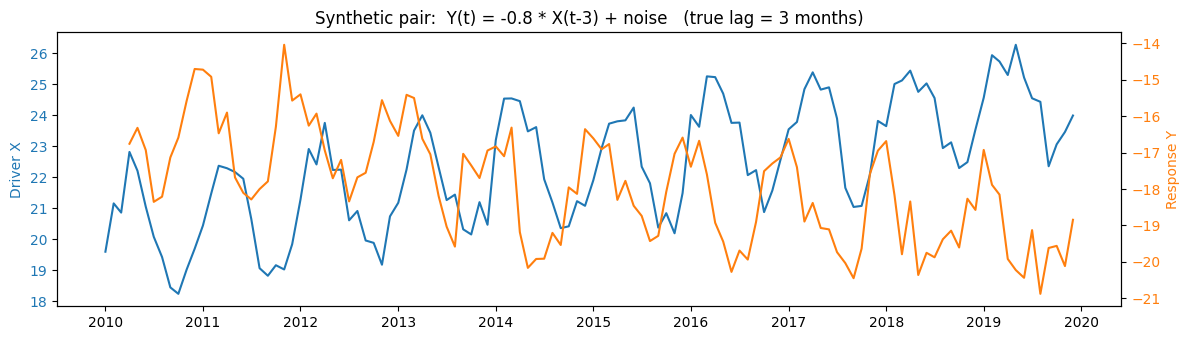

In [109]:
# 兩個「已知的正確答案」—— 待會要用互相關 `.corr()` 把它們找回來
LAG_TRUE = 3      # Y 比 X 慢 3 個月反應
COUPLING = -0.8   # 方向相反：X 高 → 3 個月後 Y 低（模仿 湧升風 → 某個水文環境條件降低）

sim2 = make_synthetic_series(n=120, slope=0.04, season_amp=2.0, noise=0.5)  # 重用 A1
driver = sim2["y"].rename("driver")                     # X：驅動者（像湧升指數）

rng = np.random.default_rng(2027)
response = (COUPLING * driver.shift(LAG_TRUE)          # 對「3 個月前的 X」反應
            + 0.5 * rng.standard_normal(len(driver))   # 再加 Y 自己的噪音, 0.5 是噪音強度，越大越亂
            ).rename("response")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(driver.index, driver, color="tab:blue")
ax.set_ylabel("Driver X", color="tab:blue"); ax.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax.twinx()
ax2.plot(response.index, response, color="tab:orange")
ax2.set_ylabel("Response Y", color="tab:orange"); ax2.tick_params(axis="y", labelcolor="tab:orange")
ax.set_title(f"Synthetic pair:  Y(t) = {COUPLING} * X(t-{LAG_TRUE}) + noise   (true lag = {LAG_TRUE} months)")
fig.tight_layout()
plt.show()
# 眼睛先看：橘線 (Y) 的谷，總是跟在藍線 (X) 的峰後面約 3 格——這就是待會要「量」出來的延遲

In [110]:
# 解釋 Cross-correlation 互相關性
# 其實只是把時間序列 Y 整條往前搬 `lag` 個月（讓「X」對齊「lag 個月後的 Y」），再算出兩者的相關係數(Pearson correlation coefficient) r；
# 每個 lag 都做一次、比較哪個 lag 的 **|r| 最大**—比如下述程式掃了 0～6 個月的相關係數（`#` 越長 = |r| 越大）：
for lag in range(0, 7):
    shifted = response.shift(-lag)               # 對齊「lag 個月後的 Y」
    m = driver.notna() & shifted.notna()         # 兩邊都有值的月份才算
    r = driver[m].corr(shifted[m])
    print(f"lag=+{lag} 月  r = {r:+.2f}  {'#' * int(abs(r) * 20)}")

lag=+0 月  r = -0.40  ########
lag=+1 月  r = -0.62  ############
lag=+2 月  r = -0.81  ################
lag=+3 月  r = -0.94  ##################
lag=+4 月  r = -0.82  ################
lag=+5 月  r = -0.65  ############
lag=+6 月  r = -0.40  ########


#### Code-4.4 討論：互相關性的陷阱 － 季節（時間序列的週期性）會製造「到處都相關」的假象
上面掃出 lag=+3 最強（r≈−0.94），看起來成功了？
X 和 Y 都帶著強季節，而任何兩條有季節的序列，每隔一個週期（12 個月）就會「自動」對齊一次——
高相關可以完全來自共同的季節，跟真正的因果（causality）無關，我們沒辦法從上述的結果得證：X 導致 Y。

把 lag 掃寬到 ±20 個月就會現形（下圖左）：除了 +3 之外，**−9、+15 的相關幾乎一樣強**。

解法就是移除共同的周期性 ：先用 **STL 把季節和趨勢拿掉、只留殘差**，再算互相關（下圖右）——
假峰消失，只剩 +3 一根乾淨的負峰。（但只是說明兩者確然互相關，仍不能得證之間的因果關係，這個觀念很重要）

    附註1：其實"確然互相關"仍可能過於武斷，實際上的相關性，還是要經過統計上的顯著性檢測。此屬進階課程，不在本次課程範圍內，但程式的寫法並不困難，有興趣可洽Google or AI.

In [111]:
def lagged_xcorr(x: pd.Series, y: pd.Series, max_lag=20):
    """
    x 與『平移後的 y』的落後互相關。lag>0 表示用『較晚的 y』對齊 x
    (即 x 領先 y)。回傳 (lags, r, p, best_lag)。先把兩者標準化 (z-score)。
    """
    from scipy.stats import pearsonr
    xz = (x - x.mean()) / x.std()
    yz = (y - y.mean()) / y.std()
    lags, rs, ps = [], [], []
    for lag in range(-max_lag, max_lag + 1):
        ys = yz.shift(-lag)               # lag>0: y 往前移 → 比較『未來的 y』
        m = xz.notna() & ys.notna()
        if m.sum() > 5:
            r, p = pearsonr(xz[m], ys[m])
            lags.append(lag); rs.append(r); ps.append(p)
    rs = np.array(rs)
    best_lag = lags[int(np.argmax(np.abs(rs)))]
    return np.array(lags), rs, np.array(ps), best_lag

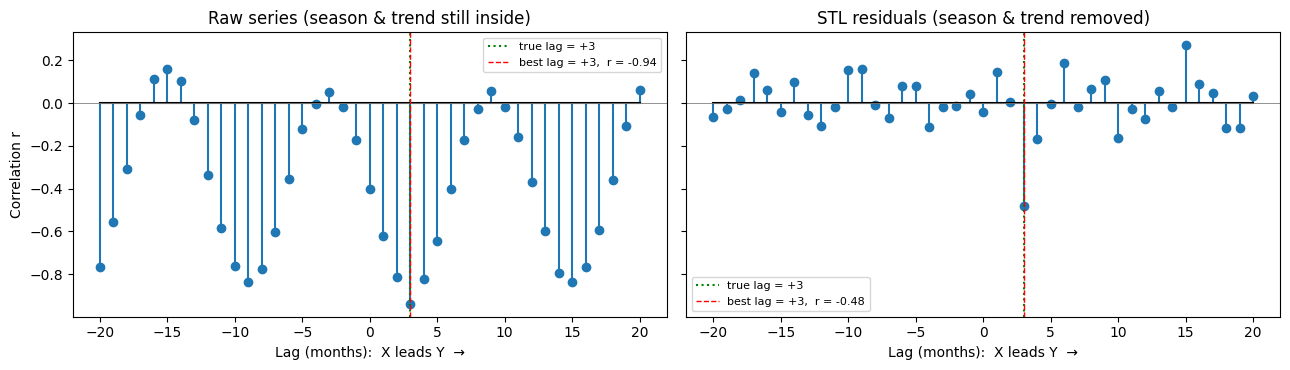

In [112]:
# 重用前面的 STL：把季節+趨勢拿掉、只留殘差，再算一次互相關來對照
drv_resid = STL(driver, period=12, robust=True).fit().resid
rsp_resid = STL(response.dropna(), period=12, robust=True).fit().resid

lags_raw, r_raw, _, best_raw = lagged_xcorr(driver, response, max_lag=20)
lags_res, r_res, _, best_res = lagged_xcorr(drv_resid, rsp_resid, max_lag=20)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, (lg, rr, bl, ttl) in zip(axes, [
        (lags_raw, r_raw, best_raw, "Raw series (season & trend still inside)"),
        (lags_res, r_res, best_res, "STL residuals (season & trend removed)")]):
    ax.stem(lg, rr, basefmt="k-")
    ax.axhline(0, color="gray", lw=0.6)
    ax.axvline(LAG_TRUE, color="green", ls=":", lw=1.5, label=f"true lag = +{LAG_TRUE}")
    ax.axvline(bl, color="red", ls="--", lw=1,
               label=f"best lag = {bl:+d},  r = {rr[list(lg).index(bl)]:.2f}")
    ax.set_xlabel("Lag (months):  X leads Y  →")
    ax.set_title(ttl)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Correlation r")
plt.tight_layout()
plt.show()

#### Code-4.4 應用：龍洞站湧升指數 V.S. SST

    附註：以下分析跟原文獻的分析已無關係，原文獻只利用衛星的SST資料在空間上探討可偵測湧升流出現的相關性，並非時間序列上的相關性。

In [113]:
# 我們在前面的段落已說明，SST距平值已經是「去季節化」的資料，這裡直接拿來和用 STL 去掉趨勢、季節性的 UI 殘差做相關性探討。
sst_clim = sst_d.groupby(sst_d.index.month).mean()         # 浮標自身的月氣候平均
sst_anom = sst_d - sst_d.index.month.map(sst_clim)         # SST 距平值
ui_resid = STL(ui_d, period=365, robust=True).fit().resid  # UI 殘差
window = slice("2016-04-10", "2016-10-15")                 # 聚焦在論文中 2016 年的湧升季節

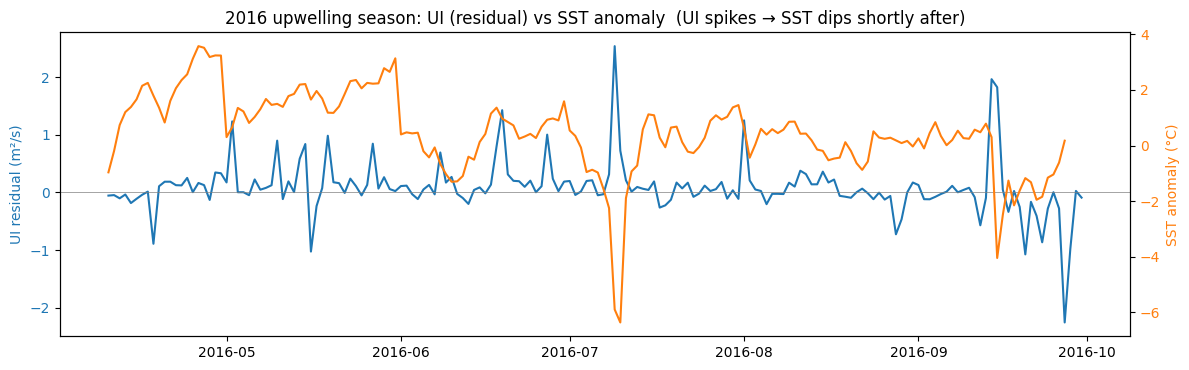

In [114]:
# 疊圖：直接用肉眼比較兩條時間序列，
ui_w = ui_resid.loc[window]
anom_w = sst_anom.loc[window]
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(ui_w.index, ui_w, color="tab:blue", label="Upwelling index (UI)")
ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel("UI residual (m²/s)", color="tab:blue"); ax.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax.twinx()
ax2.plot(anom_w.index, anom_w, color="tab:orange", label="SST anomaly")
ax2.set_ylabel("SST anomaly (°C)", color="tab:orange"); ax2.tick_params(axis="y", labelcolor="tab:orange")
ax.set_title("2016 upwelling season: UI (residual) vs SST anomaly  (UI spikes → SST dips shortly after)")
fig.tight_layout()
plt.show()

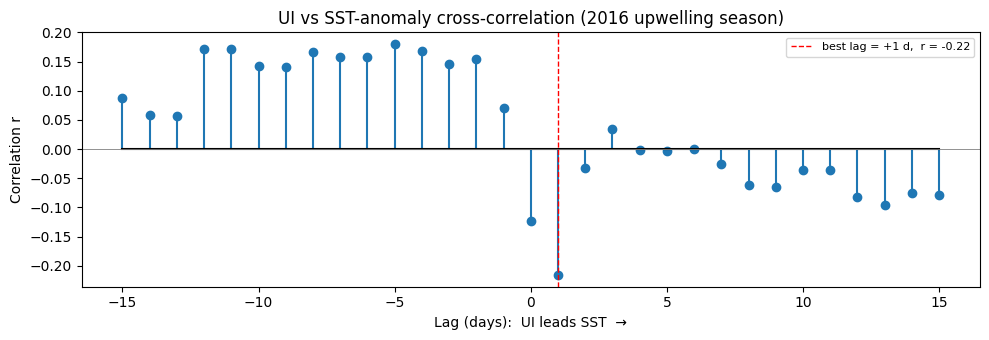

In [115]:
# 本圖也是投影片 13 結果
# 看到 pattern 後實際計算互相關性，的確，在 lag=+1 時有最大負相關，符合「湧升流 → 海表溫下降」的直覺。
# 但問題就來了：是不是所有年份的時間序列，都能重現這樣的互相關性？ Honestly, 不一定。這只是一個特例嗎？
corr_df = pd.concat([ui_resid.rename("ui_resid"),
                     sst_anom.rename("sst_anom")], axis=1, join="inner").dropna()
win = corr_df.loc[window]
lags, rs, ps, best = lagged_xcorr(win["ui_resid"], win["sst_anom"], max_lag=15)
r_best = rs[list(lags).index(best)]

plt.figure(figsize=(10, 3.5))
plt.stem(lags, rs, basefmt="k-")
plt.axhline(0, color="gray", lw=0.6)
plt.axvline(best, color="red", ls="--", lw=1,
            label=f"best lag = +{best} d,  r = {r_best:.2f}")
plt.xlabel("Lag (days):  UI leads SST  →")
plt.ylabel("Correlation r")
plt.title("UI vs SST-anomaly cross-correlation (2016 upwelling season)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Code-4 結論
- 本案例只看了 2016 一年，得到一個看似漂亮的相關性結果 —— 如果把**完全一樣**的計算套用在 2010–2024 每一個湧升流季，其實會得到很多在物理現象說不通的相關性
- 這是 **相關性** 的 misinterpretation: 盲人騎瞎馬

![Misinterpretaion of correlation](./lectures/Timeseries_correlation_misinterpretation.png)

- 進階思考1：把**每一年的整條 r(lag) 曲線疊起來平均** － 這樣就不必挑年份，也不必挑 lag。
1. 真訊號每年都在同一個 lag、同一個方向，會**疊加**
2. 雜訊的假峰每年落在不同位置，會**互相抵消**

- 進階思考2：如果利用我們前面說的，把時間序列換成事件來探討 － 也就是定義 **顯著的湧升訊號事件**
1. 連續 **≥5 天** UI > 0
2. 且**前 5 天累積 UI ≥ 2.0** m²/s（同時要求「夠久」和「夠強」）
3. 然後把把每個顯著事件的起風日對齊成 day 0，取 SST 距平值的平均，再將結果疊合。

* 這兩個進一步思考，都會得到有意義的結果，如果有興趣，未來可做進一步Code實作。


## 投影片 14 — Take Home Messages

- 開源函式庫 **+ AI + Vibe coding** 已經使資料處理技術不再是最大門檻
  - 了解資料的本質與如何應用，才能驅動 **AI** 幫忙做出有用的事
  - 做為入門的第一步：找到適合的科學文獻參考，幫助頗大！
- 初探時間序列：
  - 時間序列的相關性、因果關係，往往存在錯誤陷阱與迷思
    - 時間拉長，真實世界的時間訊號往往都具非線性、複雜因子，所謂的相關性往往不復存在
  - 將連續的時間序列，轉換成指數、事件，常有助於對影響因子的統計分析